In [1]:
import json
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
LAYERS = [
    "conv1",
    "layer1.0", "layer1.1", "layer1.2",
    "layer2.0", "layer2.1", "layer2.2", "layer2.3",
    "layer3.0", "layer3.1", "layer3.2", "layer3.3", "layer3.4", "layer3.5",
    "layer4.0", "layer4.1", "layer4.2",
    "avgpool",
]

EMERGE_METRIC = "balanced"   # "balanced" | "plain"
EMERGE_FRAC   = 0.90         # e.g. 0.90 | 0.95

# ── Choose emergence criterion + tag pre / at / post ──────────────────────────
# EMERGE_CRITERION reads emerge_idx_frac (uses EMERGE_FRAC) or emerge_idx_jump
# Both were computed by attribute_emergence() using EMERGE_METRIC and EMERGE_FRAC above.
EMERGE_CRITERION = "sharp_jump"    # "frac90" | "sharp_jump"
emerge_col = "emerge_idx_frac"   if EMERGE_CRITERION == "frac90" else "emerge_idx_jump"
layer_col  = "emerge_layer_frac" if EMERGE_CRITERION == "frac90" else "emerge_layer_jump"

In [3]:
import sys
ROOT = Path('/scratch/network/cr7998/cv_emergence_project')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FB         = ROOT / 'data'     / 'FunnyBirds'
BASE_FEATS = ROOT / 'features' / 'resnet50_funnybirds'
CBM_FEATS  = ROOT / 'features' / 'resnet50_cbm_funnybirds'

assert FB.exists(),                           f'Missing FunnyBirds folder: {FB}'
assert (FB / 'dataset_train.json').exists(),  f'Missing dataset_train.json: {FB}'

for name, d in [('baseline', BASE_FEATS), ('cbm', CBM_FEATS)]:
    if not d.exists(): print(f'  [warn] {name} features not extracted: {d}')
    else:              print(f'  [ok]   {name}: {d}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[config] device: {device}')

  [ok]   baseline: /scratch/network/cr7998/cv_emergence_project/features/resnet50_funnybirds
  [ok]   cbm: /scratch/network/cr7998/cv_emergence_project/features/resnet50_cbm_funnybirds
[config] device: cpu


In [4]:
def load_species_maps(fb_root: Path):
    """
    Load species ID→name mappings from FunnyBirds metadata/classes.csv.
    Mirrors load_species_maps(cub_root) in recall.ipynb.
    """
    classes_csv = fb_root / "metadata" / "classes.csv"
    if not classes_csv.exists():
        raise FileNotFoundError(
            "metadata/classes.csv not found. Run prepare_funnybirds_metadata.py first."
        )
    df = pd.read_csv(classes_csv)
    id2name  = dict(zip(df["class_id"], df["class_name"]))
    id2short = {k: v.replace("funnybird_", "FB") for k, v in id2name.items()}
    return id2name, id2short


def load_meta(fb_root: Path) -> pd.DataFrame:
    """
    Load per-image metadata with species information.
    Returns DataFrame with columns: image_id, class_id, species_id, species_name, is_train.
    Mirrors load_meta(cub_root) in recall.ipynb.
    """
    images_csv = fb_root / "metadata" / "images.csv"
    if not images_csv.exists():
        raise FileNotFoundError(
            "metadata/images.csv not found. Run prepare_funnybirds_metadata.py first."
        )
    df = pd.read_csv(images_csv)
    id2name, _ = load_species_maps(fb_root)
    df["species_id"]   = df["class_id"]
    df["species_name"] = df["class_id"].map(id2name)
    return df


def load_image_attr_labels_robust(fb_root: Path) -> pd.DataFrame:
    """
    Load per-image binary concept labels from metadata/image_concepts_binary.csv.
    Mirrors load_image_attr_labels_robust(cub_root) in recall.ipynb.

    Returns long-form DataFrame: image_id, attr_id, attr_name, is_present, certainty.
    certainty is always 1 for FunnyBirds (ground-truth, no annotation noise).
    """
    concepts_csv = fb_root / "metadata" / "image_concepts_binary.csv"
    if not concepts_csv.exists():
        raise FileNotFoundError(
            "metadata/image_concepts_binary.csv not found. "
            "Run prepare_funnybirds_metadata.py first."
        )
    wide = pd.read_csv(concepts_csv)
    concept_cols = [c for c in wide.columns if c != "image_id"]
    long = wide.melt(
        id_vars="image_id", value_vars=concept_cols,
        var_name="attr_name", value_name="is_present"
    )
    long["attr_id"]    = long.groupby("attr_name", sort=False).ngroup()
    long["is_present"] = long["is_present"].astype(int)
    long["certainty"]  = 1   # FunnyBirds: ground-truth, always certain
    return long[["image_id", "attr_id", "attr_name", "is_present", "certainty"]]


def load_attr_maps(fb_root: Path):
    """
    Load concept names from metadata/concepts.csv.
    Mirrors load_attr_maps(attr_txt) in recall.ipynb.
    Returns: attr_id_to_name, attr_name_to_id
    """
    concepts_csv = fb_root / "metadata" / "concepts.csv"
    if not concepts_csv.exists():
        raise FileNotFoundError(
            "metadata/concepts.csv not found. Run prepare_funnybirds_metadata.py first."
        )
    df = pd.read_csv(concepts_csv)
    id2name  = dict(zip(df["concept_id"], df["concept_name"]))
    name2id  = dict(zip(df["concept_name"], df["concept_id"]))
    return id2name, name2id

In [5]:
# FunnyBirds: all 26 concepts (no prevalence filter needed — one-hot per part group)
from datasets.funnybirds_dataset import concept_names as _fb_concept_names
ATTR_LIST = _fb_concept_names()
print(f"FunnyBirds concepts ({len(ATTR_LIST)}): {ATTR_LIST}")

FunnyBirds concepts (26): ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']


In [6]:
# Class-concept matrix: every row = species, every column = one of 26 part-variant concepts.
# EXACT ground truth — no annotation noise. Key FunnyBirds advantage.
from datasets.funnybirds_dataset import FunnyBirdsDataset
_fb_ds = FunnyBirdsDataset(FB, split="train")
class_concept_matrix, _ = _fb_ds.get_class_concept_matrix()

cc_df = pd.DataFrame(
    class_concept_matrix.numpy(),
    columns=_fb_concept_names(),
    index=[f"funnybird_{i:02d}" for i in range(class_concept_matrix.shape[0])],
)
print(f"Class-concept matrix shape: {cc_df.shape}")
print("Each row should sum to 5 (one variant per part per species):")
print(cc_df.sum(axis=1).value_counts())
print("\nFirst 5 species:")
cc_df.head()

Class-concept matrix shape: (50, 26)
Each row should sum to 5 (one variant per part per species):
5.0    30
3.0     7
4.0     4
2.0     4
0.0     3
1.0     2
Name: count, dtype: int64

First 5 species:


,beak_0,beak_1,beak_2,beak_3,eye_0,eye_1,eye_2,wing_0,wing_1,wing_2,...,foot_3,tail_0,tail_1,tail_2,tail_3,tail_4,tail_5,tail_6,tail_7,tail_8
funnybird_00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
funnybird_01,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
funnybird_02,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
funnybird_03,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
funnybird_04,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Load metadata, concept labels, and attribute maps
meta          = load_meta(FB)
img_attr_long = load_image_attr_labels_robust(FB)
attr_id_to_name, attr_name_to_id = load_attr_maps(FB)

# attr_df: one row per concept — mirrors CUB attr_df used downstream
attr_df = pd.DataFrame({
    "attr_name": list(attr_name_to_id.keys()),
    "attr_id":   list(attr_name_to_id.values()),
})

# spname: species id → display name (used throughout matched-pair eval)
id2name, _ = load_species_maps(FB)
def spname(sid: int) -> str:
    return id2name.get(int(sid), f"funnybird_{int(sid):02d}")

print(f"meta: {len(meta)} images  "
      f"({meta['is_train'].sum()} train, {(meta['is_train']==0).sum()} test)")
print(f"img_attr_long: {len(img_attr_long)} rows, "
      f"{img_attr_long['attr_name'].nunique()} concepts")
print(f"attr_df: {len(attr_df)} concepts")
print(f"Concepts: {list(attr_name_to_id.keys())}")

meta: 50500 images  (50000 train, 500 test)
img_attr_long: 1313000 rows, 26 concepts
attr_df: 26 concepts
Concepts: ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']


In [8]:
# What this cell does:
# - For a given attr_id, merges meta (image->species, split) with attribute labels (image->y)
# - Produces a clean table with y in {0,1}
# Why it matters:
# - This is the ground-truth label table used for training and evaluation.

def build_attr_labeled_df(
    meta: pd.DataFrame,
    img_attr_long: pd.DataFrame,
    attr_id: int,
    min_certainty: int = 1,
) -> pd.DataFrame:
    """
    Returns dataframe with:
      image_id, species_id, species_name, is_train, y, certainty
    Only keeps annotations with certainty >= min_certainty.
    For FunnyBirds certainty is always 1, so the filter is a no-op.
    """
    sub = img_attr_long[img_attr_long["attr_id"] == int(attr_id)].copy()
    sub = sub[sub["certainty"] >= int(min_certainty)].copy()
    out = meta.merge(sub[["image_id", "is_present", "certainty"]], on="image_id", how="inner")
    out = out.rename(columns={"is_present": "y"})
    out["y"] = out["y"].astype(int)
    return out[["image_id", "species_id", "species_name", "is_train", "y", "certainty"]]


print("Defined: build_attr_labeled_df")

# Sanity check on one concept
attr_name_check = "beak_0"
aid_check = attr_name_to_id[attr_name_check]
lab_check = build_attr_labeled_df(meta, img_attr_long, aid_check, min_certainty=1)
print(f"Attribute: {attr_name_check}  rows labeled: {len(lab_check)}  "
      f"pos rate: {lab_check.y.mean():.4f}")
lab_check.head()

Defined: build_attr_labeled_df
Attribute: beak_0  rows labeled: 50500  pos rate: 0.3174


,image_id,species_id,species_name,is_train,y,certainty
0,0,0,funnybird_00,1,0,1
1,1,0,funnybird_00,1,0,1
2,2,0,funnybird_00,1,0,1
3,3,0,funnybird_00,1,0,1
4,4,0,funnybird_00,1,0,1


In [9]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f"{layer}_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()


def to_1d_int_array(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)


def infer_kind(arr):
    if arr.max() <= 200 and arr.min() >= 0:
        return "species_id_like"
    if arr.max() > 200:
        return "image_id_like"
    return "unknown"


def load_split_order(feat_dir, split):
    p = feat_dir / f"labels_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    t = safe_torch_load(p)
    assert isinstance(t, dict), f"Expected dict in {p}, got {type(t)}"
    assert "image_ids" in t, f"{p} missing 'image_ids' key; has {list(t.keys())}"
    ids  = to_1d_int_array(t["image_ids"])
    kind = infer_kind(ids)
    return kind, ids


# LAYER is NOT set here — computed dynamically from species emergence curve below
LAYER = None

base_kind_tr, base_ids_tr = load_split_order(BASE_FEATS, "train") if BASE_FEATS.exists() else (None, None)
base_kind_te, base_ids_te = load_split_order(BASE_FEATS, "test")  if BASE_FEATS.exists() else (None, None)
cbm_kind_tr,  cbm_ids_tr  = load_split_order(CBM_FEATS,  "train") if CBM_FEATS.exists()  else (None, None)
cbm_kind_te,  cbm_ids_te  = load_split_order(CBM_FEATS,  "test")  if CBM_FEATS.exists()  else (None, None)

print("BASE_FEATS available:", BASE_FEATS.exists())
print("CBM_FEATS  available:", CBM_FEATS.exists())
if BASE_FEATS.exists():
    print(f"  Baseline train: {base_kind_tr}  id range: ({base_ids_tr.min()}, {base_ids_tr.max()})")
    print(f"  Baseline test:  {base_kind_te}  id range: ({base_ids_te.min()}, {base_ids_te.max()})")

BASE_FEATS available: True
CBM_FEATS  available: True
  Baseline train: image_id_like  id range: (0, 49999)
  Baseline test:  image_id_like  id range: (50000, 50499)


In [10]:
def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return 0.5 * (tpr + tnr)


def frac_of_final_idx(vals: np.ndarray, frac: float = 0.90) -> int:
    """Earliest index i such that vals[i] >= frac * vals[-1]."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    target = frac * float(v[-1])
    for i, x in enumerate(v):
        if float(x) >= target:
            return int(i)
    return int(len(v) - 1)


def sharp_rise_idx(vals: np.ndarray) -> int:
    """Index of the largest single-step increase in vals."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    diffs = np.diff(v)
    return int(np.argmax(diffs)) + 1


def train_linear_probe_multiclass(
    Xtr, ytr, Xte, yte, *, epochs=6, lr=3e-3, wd=1e-4, seed=0, device=None,
):
    torch.manual_seed(seed)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long,    device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    d, C  = Xtr_t.shape[1], int(ytr_t.max().item()) + 1
    model = nn.Linear(d, C).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).detach().cpu().numpy()
    return float((pred == yte).mean())


def train_linear_probe_binary_weighted(
    Xtr, ytr, Xte, yte, *,
    epochs=8, lr=3e-3, wd=1e-4, seed=0, threshold=0.5, device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)
    Xtr_t  = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t  = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t  = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1, 1).to(device)
    d      = int(Xtr_t.shape[1])
    model  = nn.Linear(d, 1).to(device)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    pos    = float(ytr_np.sum())
    neg    = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        probs = np.zeros_like(yte_np, dtype=float)
        pred  = np.zeros_like(yte_np, dtype=int)
        return 0.5, float((pred == yte_np).mean()), 0.0, probs
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()
    pred = (probs >= threshold).astype(int)
    ba   = balanced_accuracy(yte_np, pred)
    return float(ba), float((pred == yte_np).mean()), float(pred.mean()), probs


print("Defined: balanced_accuracy  frac_of_final_idx  sharp_rise_idx")
print("Defined: train_linear_probe_multiclass  train_linear_probe_binary_weighted")

Defined: balanced_accuracy  frac_of_final_idx  sharp_rise_idx
Defined: train_linear_probe_multiclass  train_linear_probe_binary_weighted


In [11]:
import gc

# ── Alignment indices ──────────────────────────────────────────────────────────
base_ids_tr_int = np.asarray(base_ids_tr, dtype=int)
base_ids_te_int = np.asarray(base_ids_te, dtype=int)

meta_tr_set = set(meta[meta["is_train"] == 1]["image_id"].astype(int))
meta_te_set = set(meta[meta["is_train"] == 0]["image_id"].astype(int))

keep_tr_idx = np.array([i for i, iid in enumerate(base_ids_tr_int) if iid in meta_tr_set], dtype=int)
keep_te_idx = np.array([i for i, iid in enumerate(base_ids_te_int) if iid in meta_te_set], dtype=int)

aligned_tr_ids = base_ids_tr_int[keep_tr_idx]
aligned_te_ids = base_ids_te_int[keep_te_idx]

# ── Load all layers — slice immediately, never keep full unindexed tensors ─────
aligned_base_tr = {L: load_features(BASE_FEATS, L, "train")[keep_tr_idx] for L in LAYERS}
aligned_base_te = {L: load_features(BASE_FEATS, L, "test")[keep_te_idx]  for L in LAYERS}
gc.collect()

print(f"Loaded {len(LAYERS)} layers.  layer4.0 shape: {aligned_base_tr['layer4.0'].shape}")

# ── Species labels — offset by min species_id so indices are always 0-based ───
_meta_idx = meta.set_index("image_id")
_sid_min  = int(meta["species_id"].min())

ysp_tr_ba = _meta_idx.loc[aligned_tr_ids, "species_id"].to_numpy(dtype=np.int64) - _sid_min
ysp_te_ba = _meta_idx.loc[aligned_te_ids, "species_id"].to_numpy(dtype=np.int64) - _sid_min

assert ysp_tr_ba.min() >= 0, "Negative class index — species_id offset wrong!"
print(f"species_id range: {_sid_min} → {int(meta['species_id'].max())}  (offset={_sid_min})")
print(f"ysp_tr_ba range: {ysp_tr_ba.min()} → {ysp_tr_ba.max()}")

# ── Species emergence curve — computed NOW so LAYER can be set dynamically ─────
# Must run before screening and run_many, both of which need LAYER.
print("\nComputing species emergence curve across layers...")
species_curve_ba = np.array([
    train_linear_probe_multiclass(
        aligned_base_tr[L], ysp_tr_ba,
        aligned_base_te[L], ysp_te_ba,
        epochs=15, seed=0,
    )
    for L in LAYERS
], dtype=float)

species_emerge_idx_jump = sharp_rise_idx(species_curve_ba)
species_emerge_idx_frac = frac_of_final_idx(species_curve_ba, frac=EMERGE_FRAC)

print(f"\nSpecies emergence:")
print(f"  sharp_jump : layer index {species_emerge_idx_jump} = {LAYERS[species_emerge_idx_jump]}"
      f"  (acc={species_curve_ba[species_emerge_idx_jump]:.3f})")
print(f"  frac{int(EMERGE_FRAC*100)}     : layer index {species_emerge_idx_frac} = {LAYERS[species_emerge_idx_frac]}"
      f"  (acc={species_curve_ba[species_emerge_idx_frac]:.3f})")

# ── Set LAYER from the configured criterion ────────────────────────────────────
if EMERGE_CRITERION == "frac90":
    species_emerge_idx_ba = species_emerge_idx_frac
else:
    species_emerge_idx_ba = species_emerge_idx_jump

LAYER = LAYERS[species_emerge_idx_ba]
print(f"\nLAYER set to: {LAYER}  (criterion: {EMERGE_CRITERION})")

assert aligned_base_tr[LAYERS[0]].shape[0] == len(aligned_tr_ids)
assert aligned_base_te[LAYERS[0]].shape[0] == len(aligned_te_ids)
print("Feature / label alignment OK")

Loaded 18 layers.  layer4.0 shape: torch.Size([50000, 2048])
species_id range: 0 → 49  (offset=0)
ysp_tr_ba range: 0 → 49

Computing species emergence curve across layers...

Species emergence:
  sharp_jump : layer index 14 = layer4.0  (acc=0.986)
  frac90     : layer index 14 = layer4.0  (acc=0.986)

LAYER set to: layer4.0  (criterion: sharp_jump)
Feature / label alignment OK


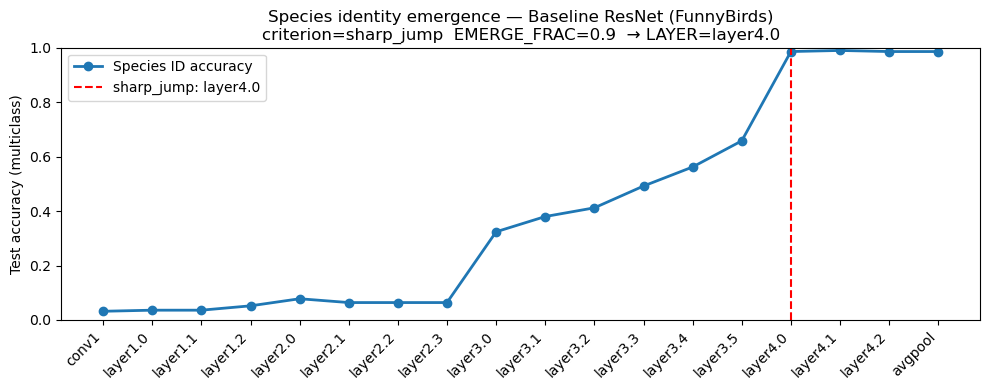

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(species_curve_ba, marker="o", linewidth=2, label="Species ID accuracy")
ax.axvline(species_emerge_idx_ba, color="red", linestyle="--", linewidth=1.5,
           label=f"{EMERGE_CRITERION}: {LAYER}")
ax.set_xticks(range(len(LAYERS)))
ax.set_xticklabels(LAYERS, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Test accuracy (multiclass)")
ax.set_title(
    f"Species identity emergence — Baseline ResNet (FunnyBirds)\n"
    f"criterion={EMERGE_CRITERION}  EMERGE_FRAC={EMERGE_FRAC}  → LAYER={LAYER}"
)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# What this cell does:
# - Aligns features (in feature row order) to attribute labels by image_id.
# - Produces X_aligned and df_aligned with the same ordering.

def align_features_and_labels(
    X_split: torch.Tensor,
    image_ids_in_feature_order: np.ndarray,
    labeled_df_split: pd.DataFrame,
):
    """
    Inputs:
      X_split: feature tensor [N, D]
      image_ids_in_feature_order: length N
      labeled_df_split: DataFrame with [image_id, y, species_id, species_name]
    Output:
      X_aligned, df_aligned (same ordering, only images that have labels)
    """
    labeled  = labeled_df_split.set_index("image_id")[["y", "species_id", "species_name"]]
    keep_idx = []
    rows     = []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id]
            rows.append((img_id, int(sid), str(sname), int(y)))
    X_aligned  = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows, columns=["image_id", "species_id", "species_name", "y"])
    return X_aligned, df_aligned

In [14]:
# What this cell does:
# - Defines a linear probe (single linear layer).
# - Trains with BCEWithLogitsLoss + mild class-imbalance handling.
# Why it matters:
# - Probe is the measurement instrument: "is the attribute encoded in features?"

class LinearProbe(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.lin = nn.Linear(d, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)


def train_probe(
    Xtr: torch.Tensor, ytr: np.ndarray,
    seed=0, lr=1e-2, wd=1e-4, epochs=25, batch=512,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    Xtr   = Xtr.to(device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)
    probe = LinearProbe(Xtr.shape[1]).to(device)
    opt   = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)
    pos   = float(ytr_t.mean().item())
    pos_weight = (
        torch.tensor([(1 - pos) / pos], device=device)
        if 0 < pos < 1
        else torch.tensor([1.0], device=device)
    )
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    n = Xtr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx    = perm[i:i+batch]
            logits = probe(Xtr[idx])
            loss   = loss_fn(logits, ytr_t[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
    return probe


@torch.no_grad()
def predict_probs(probe: nn.Module, X: torch.Tensor, batch=4096) -> np.ndarray:
    probe.eval()
    probs = []
    for i in range(0, X.shape[0], batch):
        xb = X[i:i+batch].to(device)
        logits = probe(xb)
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()


print("Defined: LinearProbe  train_probe  predict_probs")

Defined: LinearProbe  train_probe  predict_probs


In [15]:
# What this cell does:
# - Finds species that have enough positives and negatives for the chosen attribute.
# - Samples many species pairs.
# - For each pair, subsamples to match prevalence exactly and computes recall on positives.
# Why it matters:
# - This isolates species-specific recall differences even when prevalence is controlled.
#
# FunnyBirds note: every attribute is fixed per species (all-positive or all-negative —
# no within-species variation). make_candidate_pairs always returns 0 pairs.
# make_candidate_pairs_fb instead pairs two ALL-POSITIVE species and measures whether
# the probe recalls the attribute equally well for both, giving the same entanglement
# signal without requiring within-species negatives.

def make_candidate_pairs(df_test: pd.DataFrame, min_each=10, max_pairs=200, seed=0):
    """
    Returns list of (sid_A, sid_B, mpos, mneg) 4-tuples.
    For FunnyBirds this usually returns [] — use make_candidate_pairs_fb instead.
    """
    g    = df_test.groupby("species_id")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
    g["neg"] = g["count"] - g["pos"]
    ok   = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()
    rng  = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2:
        return pairs
    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos, mneg))
        if len(pairs) >= max_pairs:
            break
    return pairs


def make_candidate_pairs_fb(df_test: pd.DataFrame, min_pos: int = 3,
                             max_pairs: int = 200, seed: int = 0):
    """
    FunnyBirds variant: enumerates ALL pairs of all-positive species
    (prevalence >= 0.9, n_pos >= min_pos).

    Returns list of (sid_A, sid_B, mpos) 3-tuples where
    mpos = min(n_pos_A, n_pos_B).

    Entanglement signal: if the probe fires differently on images from species A vs B
    even though both truly have the attribute → species-identity leakage.
    """
    from itertools import combinations as _combinations
    g    = df_test.groupby("species_id")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
    g["prev"] = g["pos"] / g["count"]
    ok   = g[(g["pos"] >= min_pos) & (g["prev"] >= 0.9)]
    sids = ok.index.tolist()
    pairs = []
    for a, b in _combinations(sids, 2):
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        pairs.append((int(a), int(b), mpos))
        if len(pairs) >= max_pairs:
            break
    return pairs

In [16]:
def matched_pair_eval(
    df_test: pd.DataFrame, probs: np.ndarray,
    sid_A: int, sid_B: int, mpos: int, mneg: int,
    seed=0, thr=0.5,
):
    """
    CUB-style: subsamples mpos positives + mneg negatives from each species.
    Computes recall on positive examples only.
    (Used when standard pairs exist; for FunnyBirds use fb_pair_eval.)
    """
    df = df_test.copy()
    df["prob"] = probs
    A = df[df.species_id == sid_A]
    B = df[df.species_id == sid_B]
    A_s = pd.concat([A[A.y==1].sample(mpos, random_state=seed),
                     A[A.y==0].sample(mneg, random_state=seed)])
    B_s = pd.concat([B[B.y==1].sample(mpos, random_state=seed),
                     B[B.y==0].sample(mneg, random_state=seed)])

    def recall_pos(d):
        pos  = d[d.y == 1]
        pred = (pos.prob.values >= thr).astype(int)
        return float((pred == 1).mean()) if len(pos) else np.nan

    recA = recall_pos(A_s)
    recB = recall_pos(B_s)
    return {
        "sid_A": sid_A, "sid_B": sid_B,
        "species_A": spname(sid_A), "species_B": spname(sid_B),
        "npos": int(mpos), "nneg": int(mneg),
        "recall_A": float(recA), "recall_B": float(recB),
        "gap": float(abs(recA - recB)),
    }


def fb_pair_eval(
    df_test: pd.DataFrame, probs: np.ndarray,
    sid_A: int, sid_B: int, mpos: int,
    seed: int = 0, thr: float = 0.5,
):
    """
    FunnyBirds variant of matched_pair_eval for all-positive species pairs.

    Samples mpos images (with replacement for bootstrap) from each all-positive species
    and computes recall = fraction classified positive. No negatives are drawn.
    The gap is the absolute difference in recall between species A and B.
    """
    df = df_test.copy()
    df["prob"] = probs
    A = df[(df.species_id == sid_A) & (df.y == 1)]
    B = df[(df.species_id == sid_B) & (df.y == 1)]
    n_A = min(mpos, len(A))
    n_B = min(mpos, len(B))
    #A_s = A.sample(n_A, random_state=seed, replace=(n_A < mpos))
    #B_s = B.sample(n_B, random_state=seed, replace=(n_B < mpos))

    # for abv, replace is only True when you don't have enough images. But for FunnyBirds test set with say 10 images per species and mpos=10, you're sampling all 10 from 10 without replacement — which always returns the same set regardless of seed. The bootstrap loop runs 100 times and picks identical images every time.

    A_s = A.sample(n_A, random_state=seed, replace=True)
    B_s = B.sample(n_B, random_state=seed, replace=True)

    def recall_pos(d):
        pred = (d.prob.values >= thr).astype(int)
        return float(pred.mean()) if len(d) > 0 else np.nan

    recA = recall_pos(A_s)
    recB = recall_pos(B_s)

    # Fixed: recall_pos returns np.nan (not None) on empty — check with np.isnan
    rec_A_valid = not np.isnan(recA)
    rec_B_valid = not np.isnan(recB)
    return {
        "sid_A": sid_A, "sid_B": sid_B,
        "species_A": spname(sid_A), "species_B": spname(sid_B),
        "npos": int(mpos), "nneg": 0,
        "recall_A": float(recA) if rec_A_valid else np.nan,
        "recall_B": float(recB) if rec_B_valid else np.nan,
        "gap": float(abs(recA - recB)) if (rec_A_valid and rec_B_valid) else np.nan,
    }


In [17]:
def bootstrap_ci(x, alpha=0.05):
    """
    Percentile bootstrap CI for a 1D array x.
    Returns (lo, hi). If x is empty or all-nan, returns (nan, nan).
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return (float(np.quantile(x, alpha / 2)),
            float(np.quantile(x, 1 - alpha / 2)))


def bootstrap_p_value(values, null=0.0):
    """
    Two-sided bootstrap p-value for H0: E[value] == null.
    p = 2 * min(P(value <= null), P(value >= null))
    """
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan
    return float(2.0 * min(np.mean(v <= null), np.mean(v >= null)))


def safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.full_like(a, np.nan, dtype=float)
    m = b != 0
    out[m] = a[m] / b[m]
    return out

In [18]:
def _build_pair_summary(res_long: pd.DataFrame) -> pd.DataFrame:
    """Shared aggregation logic for both CUB and FunnyBirds bootstrap summaries."""
    def _ci_lo(x): return bootstrap_ci(x)[0]
    def _ci_hi(x): return bootstrap_ci(x)[1]

    pair_summary = (
        res_long.groupby(["sid_A", "sid_B", "species_A", "species_B"], as_index=False)
        .agg(
            npos=(    "npos", "min"),
            nneg=(    "nneg", "min"),
            gap_mean=("gap",  "mean"),
            gap_std=( "gap",  "std"),
            gap_ci_lo=("gap", _ci_lo),
            gap_ci_hi=("gap", _ci_hi),
            gap_p=(   "gap",  bootstrap_p_value),
            n_runs=(  "gap",  "size"),
        )
    )
    EPS = 1e-12
    pair_summary["gap_ci_width"] = pair_summary["gap_ci_hi"] - pair_summary["gap_ci_lo"]
    pair_summary["gap_snr"]      = pair_summary["gap_mean"] / (pair_summary["gap_std"].fillna(0.0) + EPS)
    pair_summary["gap_norm"]     = pair_summary["gap_mean"]
    return pair_summary.sort_values("gap_mean", ascending=False).reset_index(drop=True)


def matched_pair_bootstrap_summary(df_te, probs, pairs, *, thr=0.5, B=300):
    """
    CUB-style: for each (sid_A, sid_B, mpos, mneg) 4-tuple, runs matched_pair_eval B times.
    Returns (res_long, pair_summary).
    """
    _SCOLS = ["sid_A","sid_B","species_A","species_B","npos","nneg",
              "gap_mean","gap_std","gap_ci_lo","gap_ci_hi","gap_p",
              "gap_ci_width","gap_snr","gap_norm","n_runs"]
    if pairs is None or len(pairs) == 0:
        return pd.DataFrame(), pd.DataFrame(columns=_SCOLS)
    rows = []
    for (a, b, mpos, mneg) in pairs:
        for boot_id in range(B):
            r = matched_pair_eval(df_te, probs,
                                  sid_A=int(a), sid_B=int(b),
                                  mpos=int(mpos), mneg=int(mneg),
                                  seed=int(boot_id), thr=float(thr))
            r["boot_id"] = int(boot_id)
            rows.append(r)
    res_long = pd.DataFrame(rows)
    if res_long.empty:
        return res_long, pd.DataFrame(columns=_SCOLS)
    return res_long, _build_pair_summary(res_long)


def fb_bootstrap_summary(df_te, probs, pairs, *, thr=0.5, B=300):
    """
    FunnyBirds variant: for each (sid_A, sid_B, mpos) 3-tuple, runs fb_pair_eval B times.
    Returns same column schema as matched_pair_bootstrap_summary so downstream is unchanged.
    """
    _SCOLS = ["sid_A","sid_B","species_A","species_B","npos","nneg",
              "gap_mean","gap_std","gap_ci_lo","gap_ci_hi","gap_p",
              "gap_ci_width","gap_snr","gap_norm","n_runs"]
    if pairs is None or len(pairs) == 0:
        return pd.DataFrame(), pd.DataFrame(columns=_SCOLS)
    rows = []
    for (a, b, mpos) in pairs:
        for boot_id in range(B):
            r = fb_pair_eval(df_te, probs,
                             sid_A=int(a), sid_B=int(b),
                             mpos=int(mpos), seed=int(boot_id), thr=float(thr))
            r["boot_id"] = int(boot_id)
            rows.append(r)
    res_long = pd.DataFrame(rows)
    if res_long.empty:
        return res_long, pd.DataFrame(columns=_SCOLS)
    res_long = res_long.dropna(subset=["gap"])
    if res_long.empty:
        return res_long, pd.DataFrame(columns=_SCOLS)
    return res_long, _build_pair_summary(res_long)

In [19]:
def species_recall_prevalence_table(df_te: pd.DataFrame, probs: np.ndarray, thr=0.5) -> pd.DataFrame:
    """
    Per-species table on the TEST set:
      n, n_pos, n_neg, prevalence, tp, recall, precision
    """
    df = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    df["pred"] = (df["prob"] >= thr).astype(int)
    g = (
        df.groupby(["species_id", "species_name"], as_index=False)
        .agg(n=("y","size"), n_pos=("y","sum"), n_pred_pos=("pred","sum"))
    )
    g["n_neg"]      = g["n"] - g["n_pos"]
    g["prevalence"] = g["n_pos"] / g["n"]
    tp = (
        df[df["y"] == 1]
        .groupby(["species_id", "species_name"])["pred"]
        .sum()
        .reset_index(name="tp")
    )
    out = g.merge(tp, on=["species_id", "species_name"], how="left")
    out["tp"]        = out["tp"].fillna(0).astype(int)
    out["recall"]    = np.where(out["n_pos"] > 0, out["tp"] / out["n_pos"], np.nan)
    out["precision"] = np.where(out["n_pred_pos"] > 0, out["tp"] / out["n_pred_pos"], np.nan)
    return out.sort_values("n", ascending=False).reset_index(drop=True)


def add_species_bootstrap_ci(
    df_te: pd.DataFrame, probs: np.ndarray,
    thr=0.5, B=300, min_pos_for_ci=1,
) -> pd.DataFrame:
    """
    Per-species bootstrap CI for recall.
    Bootstraps within each species by resampling that species' test images with replacement.
    Adds: recall_bs_mean, recall_ci_lo, recall_ci_hi, recall_ci_width.
    """
    df  = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    rows = []
    rng  = np.random.default_rng(0)
    for (sid, sname), d in df.groupby(["species_id", "species_name"]):
        d     = d.reset_index(drop=True)
        n     = len(d)
        n_pos = int(d["y"].sum())
        if n_pos < min_pos_for_ci:
            rows.append({"species_id": int(sid), "species_name": str(sname),
                         "recall_bs_mean": np.nan, "recall_ci_lo": np.nan,
                         "recall_ci_hi": np.nan, "recall_ci_width": np.nan, "B": int(B)})
            continue
        vals = []
        for _ in range(B):
            idx = rng.integers(0, n, size=n)
            s   = d.iloc[idx]
            pos = s[s["y"] == 1]
            if len(pos) == 0:
                vals.append(np.nan)
                continue
            vals.append(float((pos["prob"].to_numpy() >= thr).mean()))
        vals = np.asarray(vals, dtype=float)
        lo, hi = bootstrap_ci(vals, alpha=0.05)
        rows.append({
            "species_id": int(sid), "species_name": str(sname),
            "recall_bs_mean": float(np.nanmean(vals)),
            "recall_ci_lo": lo, "recall_ci_hi": hi,
            "recall_ci_width": (hi - lo) if (np.isfinite(lo) and np.isfinite(hi)) else np.nan,
            "B": int(B),
        })
    ci_df = pd.DataFrame(rows)
    base  = species_recall_prevalence_table(df_te, probs, thr=thr)
    return base.merge(ci_df, on=["species_id", "species_name"], how="left")

In [20]:
def run_one_attribute(
    attr_name: str,
    feat_dir: Path,
    split_order_kind_train: str,
    split_order_train: np.ndarray,
    split_order_kind_test: str,
    split_order_test: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    epochs: int = 25,
    min_each: int = 10,
    n_pairs: int = 200,
    B_gap: int = 100,
    B_species: int = 100,
    use_balanced_acc: bool = None,   # None = read EMERGE_METRIC at call time
):
    """
    Full pipeline for ONE attribute and ONE model's features.
    use_balanced_acc=None reads EMERGE_METRIC at call time so flipping
    the global switch propagates here automatically.
    """
    _use_bal = use_balanced_acc if use_balanced_acc is not None else (EMERGE_METRIC == "balanced")

    assert (split_order_kind_train == "image_id_like" and
            split_order_kind_test  == "image_id_like"), (
        "Cannot align features to attribute labels: labels_{split}.pt is not image_id-like."
    )
    # Build per-image labels
    aid       = attr_name_to_id[attr_name]
    lab       = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
    lab_train = lab[lab["is_train"] == 1].copy()
    lab_test  = lab[lab["is_train"] == 0].copy()

    # Load precomputed features
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")

    # Align
    Xtr, df_tr = align_features_and_labels(Xtr_all, split_order_train, lab_train)
    Xte, df_te = align_features_and_labels(Xte_all, split_order_test,  lab_test)
    ytr = df_tr["y"].astype(int).to_numpy()
    yte = df_te["y"].astype(int).to_numpy()

    # Train probe + predict
    probe = train_probe(Xtr, ytr, seed=0, epochs=epochs)
    probs = predict_probs(probe, Xte)

    # Species table
    species_table = (
        add_species_bootstrap_ci(df_te, probs, thr=thr, B=B_species)
        if B_species > 0
        else species_recall_prevalence_table(df_te, probs, thr=thr)
    )

    # Overall accuracy
    if len(yte) == 0:
        test_acc = np.nan
    elif _use_bal:
        pred_bin = (probs >= thr).astype(int)
        tp = int(((pred_bin == 1) & (yte == 1)).sum())
        tn = int(((pred_bin == 0) & (yte == 0)).sum())
        fp = int(((pred_bin == 1) & (yte == 0)).sum())
        fn = int(((pred_bin == 0) & (yte == 1)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        test_acc = 0.5 * (tpr + tnr)
    else:
        test_acc = float(((probs >= thr).astype(int) == yte).mean())

    # Matched pairs — with automatic FunnyBirds fallback
    if n_pairs is None or int(n_pairs) <= 0:
        res_long     = pd.DataFrame()
        pair_summary = pd.DataFrame()
        pairs        = []
    else:
        pairs = make_candidate_pairs(df_te, min_each=min_each, max_pairs=n_pairs, seed=0)
        if len(pairs) > 0:
            res_long, pair_summary = matched_pair_bootstrap_summary(
                df_te, probs, pairs, thr=thr, B=B_gap
            )
        else:
            fb_pairs = make_candidate_pairs_fb(
                df_te, min_pos=max(1, min_each // 5), max_pairs=n_pairs
            )
            res_long, pair_summary = fb_bootstrap_summary(
                df_te, probs, fb_pairs, thr=thr, B=B_gap
            )
            pairs = fb_pairs

    mean_gap = float(pair_summary["gap_mean"].mean())        if len(pair_summary) else np.nan
    p90_gap  = float(pair_summary["gap_mean"].quantile(0.9)) if len(pair_summary) else np.nan

    info = {
        "attr":           attr_name,
        "layer":          layer,
        "n_train":        int(len(df_tr)),
        "n_test":         int(len(df_te)),
        "train_pos_rate": float(ytr.mean()) if len(ytr) else np.nan,
        "test_pos_rate":  float(yte.mean()) if len(yte) else np.nan,
        "test_acc":       float(test_acc),
        "test_acc_type":  "balanced" if _use_bal else "plain",
        "thr":            float(thr),
        "epochs":         int(epochs),
        "n_pairs":        int(len(pairs)),
        "B_gap":          int(B_gap),
        "B_species":      int(B_species),
        "mean_gap":       mean_gap,
        "p90_gap":        p90_gap,
    }
    return info, res_long, pair_summary, df_te, species_table

In [21]:
def screen_attributes_for_species_variation(
    candidate_attrs,
    feat_dir: Path,
    kind_tr: str,  ids_tr: np.ndarray,
    kind_te: str,  ids_te: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    min_pos_per_species: int  = 3,
    min_species_with_pos: int = 4,
    min_overall_prev: float   = 0.01,
    max_overall_prev: float   = 0.99,
    epochs: int = 8,
    max_attrs: int | None = None,
    verbose_every: int = 5,
    keep_error_examples: int = 5,
    B_species: int = 200,
    use_balanced_acc: bool = None,   # None = read EMERGE_METRIC at call time
):
    _use_bal = use_balanced_acc if use_balanced_acc is not None else (EMERGE_METRIC == "balanced")

    rows   = []
    errors = []
    stats  = {
        "tried": 0, "success": 0,
        "filtered_too_few_species_pos": 0,
        "filtered_prev_out_of_range":   0,
        "filtered_no_recall_vals":      0,
        "errored": 0,
    }
    cand = list(candidate_attrs)
    if max_attrs is not None:
        cand = cand[:max_attrs]

    for i, attr in enumerate(cand):
        stats["tried"] += 1
        try:
            info, _, _, _, species_table = run_one_attribute(
                attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
                layer=layer, min_certainty=min_certainty, thr=thr,
                epochs=epochs, min_each=10, n_pairs=0, B_species=B_species,
                use_balanced_acc=_use_bal,
            )
            st            = species_table.copy()
            overall_prev  = float(st["n_pos"].sum() / st["n"].sum()) if st["n"].sum() > 0 else np.nan
            st_pos        = st[st["n_pos"] >= min_pos_per_species].copy()
            n_species_pos = int(len(st_pos))
            if n_species_pos < min_species_with_pos:
                stats["filtered_too_few_species_pos"] += 1
                continue
            if not (min_overall_prev <= overall_prev <= max_overall_prev):
                stats["filtered_prev_out_of_range"] += 1
                continue
            recall_vals = st_pos["recall"].dropna().to_numpy()
            if recall_vals.size == 0:
                stats["filtered_no_recall_vals"] += 1
                continue
            stats["success"] += 1
            recall_p90_p10 = float(np.quantile(recall_vals, 0.9) - np.quantile(recall_vals, 0.1))
            rows.append({
                "attr":            attr,
                "overall_prev":    overall_prev,
                "n_species_pos":   n_species_pos,
                "recall_std":      float(np.std(recall_vals)),
                "recall_range":    float(np.max(recall_vals) - np.min(recall_vals)),
                "recall_p90_p10":  recall_p90_p10,
                "test_acc":        float(info["test_acc"]),
                "test_acc_type":   info["test_acc_type"],
                "n_test":          int(info["n_test"]),
            })
            if verbose_every and ((i + 1) % verbose_every == 0):
                print(f"[{i+1}/{len(cand)}] ok: {attr}  "
                      f"prev={overall_prev:.3f}  n_species_pos={n_species_pos}  "
                      f"test_acc({info['test_acc_type']})={info['test_acc']:.3f}")
        except Exception as e:
            stats["errored"] += 1
            if len(errors) < keep_error_examples:
                errors.append((attr, repr(e)))
            continue

    screen_df = pd.DataFrame(rows)
    print("\n--- Screening summary ---")
    print(f"  acc_type used: {_use_bal and 'balanced' or 'plain'}")
    for k, v in stats.items():
        print(f"  {k}: {v}")
    if errors:
        print("\nExample errors (first few):")
        for a, msg in errors:
            print("  ", a, "->", msg)
    if screen_df.empty:
        print("\nNo attributes passed filters.")
        return screen_df
    return screen_df.sort_values(
        ["recall_p90_p10", "recall_range", "recall_std"], ascending=False
    ).reset_index(drop=True)

In [22]:
# ── Run screening ──────────────────────────────────────────────────────────────
_screen_feat = CBM_FEATS  if CBM_FEATS.exists()  else BASE_FEATS
_screen_ktr, _screen_itr = (cbm_kind_tr, cbm_ids_tr) if CBM_FEATS.exists() else (base_kind_tr, base_ids_tr)
_screen_kte, _screen_ite = (cbm_kind_te, cbm_ids_te) if CBM_FEATS.exists() else (base_kind_te, base_ids_te)

CANDIDATE_ATTRS = attr_df["attr_name"].tolist()

screen_df = screen_attributes_for_species_variation(
    CANDIDATE_ATTRS,
    feat_dir=_screen_feat,
    kind_tr=_screen_ktr, ids_tr=_screen_itr,
    kind_te=_screen_kte, ids_te=_screen_ite,
    layer=LAYER,
    min_certainty=1, thr=0.5,
    min_pos_per_species=3, min_species_with_pos=4,
    min_overall_prev=0.01, max_overall_prev=0.99,
    epochs=8, max_attrs=None, verbose_every=5,
)

# Fixed: use SCREENED_ATTR_LIST — do NOT overwrite ATTR_LIST from In[5]
if not screen_df.empty:
    SCREENED_ATTR_LIST = screen_df["attr"].tolist()
    print(f"\nFinal SCREENED_ATTR_LIST ({len(SCREENED_ATTR_LIST)} concepts):")
    for a in SCREENED_ATTR_LIST:
        print(" ", a)
    screen_df.head(26)
else:
    print("[warn] screening removed all attributes — falling back to full ATTR_LIST")
    SCREENED_ATTR_LIST = ATTR_LIST.copy()

attr_to_spread = screen_df.set_index("attr")["recall_p90_p10"].to_dict()


[5/26] ok: eye_0  prev=0.300  n_species_pos=15  test_acc(balanced)=0.975
[10/26] ok: wing_2  prev=0.220  n_species_pos=11  test_acc(balanced)=1.000
[15/26] ok: foot_1  prev=0.200  n_species_pos=10  test_acc(balanced)=0.998
[20/26] ok: tail_2  prev=0.140  n_species_pos=7  test_acc(balanced)=0.981

--- Screening summary ---
  acc_type used: balanced
  tried: 26
  success: 25
  filtered_too_few_species_pos: 1
  filtered_prev_out_of_range: 0
  filtered_no_recall_vals: 0
  errored: 0

Final SCREENED_ATTR_LIST (25 concepts):
  tail_5
  tail_1
  tail_8
  eye_0
  beak_3
  beak_0
  foot_3
  tail_4
  beak_2
  tail_3
  eye_2
  beak_1
  wing_4
  eye_1
  wing_0
  wing_1
  wing_2
  wing_3
  wing_5
  foot_0
  foot_1
  foot_2
  tail_0
  tail_2
  tail_6


In [23]:
def run_many(
    attr_list, model_name, feat_dir,
    kind_tr, ids_tr, kind_te, ids_te,
    *,
    layer,
    min_certainty=1, thr=0.5, epochs=25,
    min_each=3, n_pairs=200, B_gap=100, B_species=100,
    use_balanced_acc=None,   # None = read EMERGE_METRIC at call time
):
    """
    Runs run_one_attribute over a list of attrs.
    use_balanced_acc=None reads EMERGE_METRIC at call time.
    Returns: info_df, pairs_df, species_df
    """
    _use_bal = use_balanced_acc if use_balanced_acc is not None else (EMERGE_METRIC == "balanced")

    all_info, all_pair_summ, all_species = [], [], []
    for attr in attr_list:
        info, _, pair_summ, _, species_table = run_one_attribute(
            attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
            layer=layer, min_certainty=min_certainty, thr=thr,
            epochs=epochs, min_each=min_each, n_pairs=n_pairs,
            B_gap=B_gap, B_species=B_species,
            use_balanced_acc=_use_bal,
        )
        info = dict(info)
        info["model"] = model_name
        all_info.append(info)
        if pair_summ is not None and len(pair_summ):
            ps = pair_summ.copy()
            ps["attr"] = attr; ps["model"] = model_name
            all_pair_summ.append(ps)
        st = species_table.copy()
        st["attr"] = attr; st["model"] = model_name
        all_species.append(st)
        print(model_name, attr,
              f"test_acc({info['test_acc_type']})=", round(info["test_acc"], 4),
              "mean_gap=", round(info["mean_gap"], 4))
    info_df    = pd.DataFrame(all_info)
    pairs_df   = pd.concat(all_pair_summ, ignore_index=True) if all_pair_summ else pd.DataFrame()
    species_df = pd.concat(all_species,   ignore_index=True) if all_species   else pd.DataFrame()
    return info_df, pairs_df, species_df

In [24]:
baseline_info, baseline_pairs, baseline_species = run_many(
    SCREENED_ATTR_LIST, "baseline", BASE_FEATS,
    base_kind_tr, base_ids_tr,
    base_kind_te, base_ids_te,
    layer=LAYER, thr=0.5, n_pairs=200, B_gap=100, B_species=100,
)

cbm_info, cbm_pairs, cbm_species = run_many(
    SCREENED_ATTR_LIST, "cbm", CBM_FEATS,
    cbm_kind_tr, cbm_ids_tr,
    cbm_kind_te, cbm_ids_te,
    layer=LAYER, thr=0.5, n_pairs=200, B_gap=100, B_species=100,
)

assert baseline_info["test_acc_type"].nunique() == 1, "Mixed acc types in baseline_info!"
assert cbm_info["test_acc_type"].nunique() == 1,      "Mixed acc types in cbm_info!"
print(f"test_acc type used: {baseline_info['test_acc_type'].iloc[0]}")

baseline_info, cbm_info


baseline tail_5 test_acc(balanced)= 0.953 mean_gap= 0.051
baseline tail_1 test_acc(balanced)= 0.9678 mean_gap= 0.0396
baseline tail_8 test_acc(balanced)= 0.9682 mean_gap= 0.0744
baseline eye_0 test_acc(balanced)= 0.9876 mean_gap= 0.0232
baseline beak_3 test_acc(balanced)= 0.9896 mean_gap= 0.0284
baseline beak_0 test_acc(balanced)= 0.9846 mean_gap= 0.0424
baseline foot_3 test_acc(balanced)= 0.991 mean_gap= 0.0304
baseline tail_4 test_acc(balanced)= 0.9658 mean_gap= 0.0465
baseline beak_2 test_acc(balanced)= 0.9955 mean_gap= 0.0
baseline tail_3 test_acc(balanced)= 0.9859 mean_gap= 0.0286
baseline eye_2 test_acc(balanced)= 0.9968 mean_gap= 0.0
baseline beak_1 test_acc(balanced)= 1.0 mean_gap= 0.0
baseline wing_4 test_acc(balanced)= 0.9938 mean_gap= 0.0186
baseline eye_1 test_acc(balanced)= 0.9877 mean_gap= 0.035
baseline wing_0 test_acc(balanced)= 0.9989 mean_gap= 0.0
baseline wing_1 test_acc(balanced)= 0.9944 mean_gap= 0.0207
baseline wing_2 test_acc(balanced)= 0.9987 mean_gap= 0.0
basel

(      attr     layer  n_train  n_test  train_pos_rate  test_pos_rate  \
 0   tail_5  layer4.0    50000     500         0.12060           0.16   
 1   tail_1  layer4.0    50000     500         0.07490           0.10   
 2   tail_8  layer4.0    50000     500         0.12118           0.16   
 3    eye_0  layer4.0    50000     500         0.22768           0.30   
 4   beak_3  layer4.0    50000     500         0.19534           0.26   
 5   beak_0  layer4.0    50000     500         0.31638           0.42   
 6   foot_3  layer4.0    50000     500         0.19516           0.26   
 7   tail_4  layer4.0    50000     500         0.06086           0.08   
 8   beak_2  layer4.0    50000     500         0.09110           0.12   
 9   tail_3  layer4.0    50000     500         0.10570           0.14   
 10   eye_2  layer4.0    50000     500         0.28696           0.38   
 11  beak_1  layer4.0    50000     500         0.14952           0.20   
 12  wing_4  layer4.0    50000     500         0.15

In [25]:
baseline_species.to_csv("baseline_species_fb.csv", index=False)
cbm_species.to_csv("cbm_species_fb.csv", index=False)
baseline_species.sort_values("tp", ascending=False).head(30)

,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
213,1,funnybird_01,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,beak_3,baseline
591,15,funnybird_15,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,beak_1,baseline
1032,6,funnybird_06,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,foot_1,baseline
789,13,funnybird_13,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,wing_1,baseline
279,3,funnybird_03,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,beak_0,baseline
791,15,funnybird_15,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,wing_1,baseline
519,44,funnybird_44,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,eye_2,baseline
276,24,funnybird_24,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,beak_0,baseline
1117,42,funnybird_42,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,tail_0,baseline
155,30,funnybird_30,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,eye_0,baseline


In [26]:
cbm_species.sort_values("tp", ascending=False).head(30)

,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
213,1,funnybird_01,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,beak_3,cbm
615,40,funnybird_40,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,wing_4,cbm
144,18,funnybird_18,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,tail_8,cbm
786,10,funnybird_10,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,wing_1,cbm
591,15,funnybird_15,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,beak_1,cbm
517,42,funnybird_42,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,eye_2,cbm
518,43,funnybird_43,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,eye_2,cbm
789,13,funnybird_13,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,wing_1,cbm
1032,6,funnybird_06,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,foot_1,cbm
791,15,funnybird_15,10,10,10,0,1.0,10,1.0,1.0,1.0,1.0,1.0,0.0,100,wing_1,cbm


In [27]:
def summarize_by_attr(pairs_df: pd.DataFrame):
    """
    Collapses per-(attr, species pair) into per-attribute summary.
    Output: gap_mean, gap_median, gap_max, n_pairs,
            frac_p_small, frac_ci_above0, gap_snr_mean
    """
    if pairs_df.empty:
        return pairs_df
    tmp = pairs_df.copy()
    tmp["_ci_above0"] = tmp["gap_ci_lo"] > 0
    tmp["_p_small"]   = tmp["gap_p"] <= 0.05
    return (
        tmp.groupby(["model", "attr"], as_index=False)
        .agg(
            gap_mean=(       "gap_mean", "mean"),
            gap_median=(     "gap_mean", "median"),
            gap_max=(        "gap_mean", "max"),
            n_pairs=(        "gap_mean", "size"),
            frac_p_small=(   "_p_small",   "mean"),
            frac_ci_above0=( "_ci_above0", "mean"),
            gap_snr_mean=(   "gap_snr",    "mean"),
        )
        .sort_values(["model", "gap_mean"], ascending=[True, False])
    )


def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k=10):
    """
    Returns top-k pairs by gap_mean for a given (model, attr).

    Column guide:
      gap_ci_lo/hi : bootstrap CI — if excludes 0, gap is stable
      gap_p        : bootstrap p-value for H0: gap==0 (two-sided)
      gap_snr      : gap_mean / gap_std — higher = more stable
      gap_norm     : gap_mean on 0..1 scale
    """
    sub  = pairs_df[(pairs_df["model"] == model) & (pairs_df["attr"] == attr)].copy()
    if sub.empty:
        return sub
    cols = ["species_A", "species_B",
            "gap_mean", "gap_ci_lo", "gap_ci_hi", "gap_p",
            "gap_std", "gap_snr", "gap_norm", "npos", "nneg", "n_runs"]
    cols = [c for c in cols if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]

In [28]:
summary = pd.concat([
    summarize_by_attr(baseline_pairs),
    summarize_by_attr(cbm_pairs),
], ignore_index=True)
summary

,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
0,baseline,tail_8,0.074429,0.0000,0.218,28,0.0,0.0,0.617823
1,baseline,tail_5,0.051000,0.0000,0.204,28,0.0,0.0,0.435385
2,baseline,tail_4,0.046500,0.0465,0.093,6,0.0,0.0,0.550992
3,baseline,beak_0,0.042400,0.0000,0.112,200,0.0,0.0,0.441404
4,baseline,tail_1,0.039600,0.0000,0.099,10,0.0,0.0,0.427394
5,baseline,wing_3,0.036800,0.0000,0.092,10,0.0,0.0,0.374958
6,baseline,eye_1,0.035025,0.0000,0.112,120,0.0,0.0,0.366691
7,baseline,tail_2,0.032000,0.0000,0.112,21,0.0,0.0,0.314397
8,baseline,foot_3,0.030436,0.0000,0.119,78,0.0,0.0,0.326647
9,baseline,tail_3,0.028571,0.0000,0.100,21,0.0,0.0,0.296385


In [29]:
for a in SCREENED_ATTR_LIST:
    print(f"\nAttribute: {a}")
    print("Baseline top pairs:")
    display(top_pairs(baseline_pairs, "baseline", a, k=10))
    print("CBM top pairs:")
    display(top_pairs(cbm_pairs, "cbm", a, k=10))


Attribute: tail_5
Baseline top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
0,funnybird_40,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
2,funnybird_26,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
3,funnybird_05,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
4,funnybird_23,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
5,funnybird_09,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
6,funnybird_11,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
1,funnybird_38,funnybird_48,0.204,0.0,0.4,0.22,0.117138,1.741542,0.204,10,0,100
22,funnybird_09,funnybird_11,0.000,0.0,0.0,2.00,0.000000,0.000000,0.000,10,0,100
19,funnybird_09,funnybird_38,0.000,0.0,0.0,2.00,0.000000,0.000000,0.000,10,0,100
20,funnybird_09,funnybird_26,0.000,0.0,0.0,2.00,0.000000,0.000000,0.000,10,0,100


CBM top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
0,funnybird_05,funnybird_09,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1,funnybird_05,funnybird_11,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
26,funnybird_05,funnybird_23,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
25,funnybird_05,funnybird_26,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
24,funnybird_05,funnybird_38,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
23,funnybird_05,funnybird_40,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
22,funnybird_05,funnybird_48,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
21,funnybird_09,funnybird_11,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
20,funnybird_09,funnybird_23,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
19,funnybird_09,funnybird_26,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100



Attribute: tail_1
Baseline top pairs:


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
1326,funnybird_17,funnybird_33,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1337,funnybird_17,funnybird_34,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1345,funnybird_17,funnybird_35,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1344,funnybird_17,funnybird_37,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1343,funnybird_17,funnybird_39,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1342,funnybird_17,funnybird_43,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1341,funnybird_33,funnybird_34,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1340,funnybird_33,funnybird_35,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1339,funnybird_33,funnybird_37,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1338,funnybird_33,funnybird_39,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100



Attribute: tail_6
Baseline top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
1347,funnybird_14,funnybird_32,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1348,funnybird_14,funnybird_41,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1349,funnybird_14,funnybird_44,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1350,funnybird_14,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1351,funnybird_32,funnybird_41,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1352,funnybird_32,funnybird_44,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1353,funnybird_32,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1354,funnybird_41,funnybird_44,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1355,funnybird_41,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1356,funnybird_44,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100


CBM top pairs:


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,nneg,n_runs
1347,funnybird_14,funnybird_32,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1348,funnybird_14,funnybird_41,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1349,funnybird_14,funnybird_44,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1350,funnybird_14,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1351,funnybird_32,funnybird_41,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1352,funnybird_32,funnybird_44,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1353,funnybird_32,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1354,funnybird_41,funnybird_44,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1355,funnybird_41,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100
1356,funnybird_44,funnybird_45,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10,0,100


In [30]:
def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return 0.5 * (tpr + tnr)


def frac_of_final_idx(vals: np.ndarray, frac: float = 0.90) -> int:
    """Earliest index i such that vals[i] >= frac * vals[-1]."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    target = frac * float(v[-1])
    for i, x in enumerate(v):
        if float(x) >= target:
            return int(i)
    return int(len(v) - 1)


def sharp_rise_idx(vals: np.ndarray) -> int:
    """Index of the largest single-step increase in vals."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    diffs = np.diff(v)
    return int(np.argmax(diffs)) + 1


def train_linear_probe_multiclass(
    Xtr, ytr, Xte, yte, *, epochs=6, lr=3e-3, wd=1e-4, seed=0, device=None,
):
    """Multiclass linear probe — returns test accuracy."""
    torch.manual_seed(seed)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long,    device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    d, C  = Xtr_t.shape[1], int(ytr_t.max().item()) + 1
    model = nn.Linear(d, C).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).detach().cpu().numpy()
    return float((pred == yte).mean())


def train_linear_probe_binary_weighted(
    Xtr, ytr, Xte, yte, *,
    epochs=8, lr=3e-3, wd=1e-4, seed=0, threshold=0.5, device=None,
):
    """
    Binary linear probe with pos_weight for class imbalance.
    Returns: (balanced_acc, plain_acc, pred_pos_rate_test, probs_test)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)
    Xtr_t  = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t  = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t  = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1, 1).to(device)
    d      = int(Xtr_t.shape[1])
    model  = nn.Linear(d, 1).to(device)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    pos    = float(ytr_np.sum())
    neg    = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        probs = np.zeros_like(yte_np, dtype=float)
        pred  = np.zeros_like(yte_np, dtype=int)
        return 0.5, float((pred == yte_np).mean()), 0.0, probs
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()
    pred = (probs >= threshold).astype(int)
    ba   = balanced_accuracy(yte_np, pred)
    return float(ba), float((pred == yte_np).mean()), float(pred.mean()), probs

Species emergence (baseline, sharp-jump): 14 -> layer4.0
  conv1         0.0320
  layer1.0      0.0360
  layer1.1      0.0360
  layer1.2      0.0520
  layer2.0      0.0780
  layer2.1      0.0640
  layer2.2      0.0640
  layer2.3      0.0640
  layer3.0      0.3240
  layer3.1      0.3800
  layer3.2      0.4120
  layer3.3      0.4920
  layer3.4      0.5620
  layer3.5      0.6580
  layer4.0      0.9860
  layer4.1      0.9900
  layer4.2      0.9860
  avgpool       0.9860


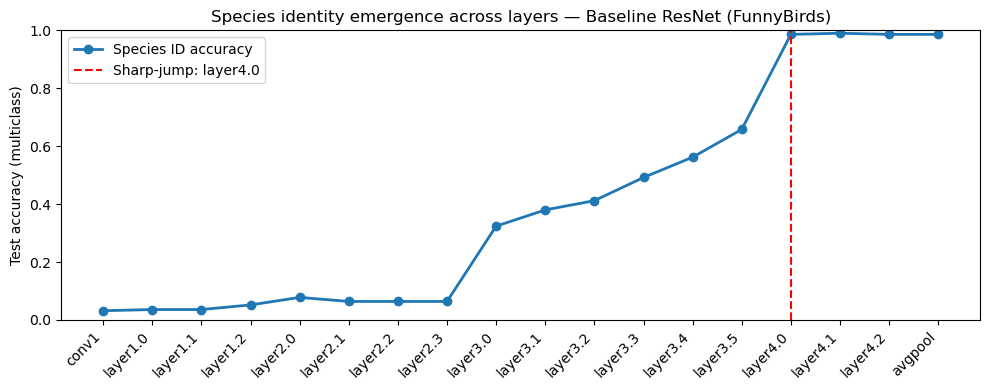

In [31]:
# Runs a multiclass linear probe (50 FunnyBirds species) at each layer
# to find the layer where species identity "emerges" in the backbone.

species_curve_ba = []
for layer in LAYERS:
    acc = train_linear_probe_multiclass(
        aligned_base_tr[layer], ysp_tr_ba,
        aligned_base_te[layer], ysp_te_ba,
        epochs=15, seed=0,
    )
    species_curve_ba.append(acc)

species_curve_ba      = np.asarray(species_curve_ba, dtype=float)
species_emerge_idx_ba = sharp_rise_idx(species_curve_ba)

print("Species emergence (baseline, sharp-jump):",
      species_emerge_idx_ba, "->", LAYERS[species_emerge_idx_ba])
for l, a in zip(LAYERS, species_curve_ba):
    print(f"  {l:12s}  {a:.4f}")

# ── Inline plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(species_curve_ba, marker="o", linewidth=2, label="Species ID accuracy")
ax.axvline(species_emerge_idx_ba, color="red", linestyle="--", linewidth=1.5,
           label=f"Sharp-jump: {LAYERS[species_emerge_idx_ba]}")
ax.set_xticks(range(len(LAYERS)))
ax.set_xticklabels(LAYERS, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Test accuracy (multiclass)")
ax.set_title("Species identity emergence across layers — Baseline ResNet (FunnyBirds)")
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
def attribute_emergence(
    attr_list, *, min_certainty=1, epochs=8, seed=0, metric=None, frac=None,
):
    """
    Computes attribute emergence indices across LAYERS.
    Uses aligned_base_tr/te (pre-sliced) and aligned_tr/te_ids.

    metric : "balanced" | "plain" | None (reads EMERGE_METRIC)
    frac   : float | None (reads EMERGE_FRAC)
    """
    _metric = metric if metric is not None else EMERGE_METRIC
    _frac   = frac   if frac   is not None else EMERGE_FRAC

    attr_labels_tr, attr_labels_te = {}, {}
    for attr in attr_list:
        aid   = attr_name_to_id[attr]
        lab   = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
        lab_i = lab.set_index("image_id")

        # Fixed: assert full coverage before .loc to catch silent NaN → int corruption
        missing_tr = set(aligned_tr_ids.tolist()) - set(lab_i.index.tolist())
        missing_te = set(aligned_te_ids.tolist()) - set(lab_i.index.tolist())
        assert not missing_tr, (
            f"{attr}: {len(missing_tr)} train image_ids missing from concept labels. "
            "Run prepare_funnybirds_metadata.py to regenerate metadata."
        )
        assert not missing_te, (
            f"{attr}: {len(missing_te)} test image_ids missing from concept labels. "
            "Run prepare_funnybirds_metadata.py to regenerate metadata."
        )

        attr_labels_tr[attr] = lab_i.loc[aligned_tr_ids, "y"].to_numpy(dtype=np.int32)
        attr_labels_te[attr] = lab_i.loc[aligned_te_ids, "y"].to_numpy(dtype=np.int32)

    rows = []
    for attr in attr_list:
        ytr, yte    = attr_labels_tr[attr], attr_labels_te[attr]
        ba_curve, acc_curve = [], []
        for layer in LAYERS:
            ba, acc, _, _ = train_linear_probe_binary_weighted(
                aligned_base_tr[layer], ytr,
                aligned_base_te[layer], yte,
                epochs=epochs, seed=seed,
            )
            ba_curve.append(ba); acc_curve.append(acc)
        ba_arr      = np.asarray(ba_curve,  dtype=float)
        acc_arr     = np.asarray(acc_curve, dtype=float)
        _emerge_arr = ba_arr if _metric == "balanced" else acc_arr
        e_jump = sharp_rise_idx(_emerge_arr)
        e_frac = frac_of_final_idx(_emerge_arr, frac=_frac)
        rows.append({
            "attr":              attr,
            "emerge_idx_jump":   int(e_jump),
            "emerge_layer_jump": LAYERS[e_jump],
            "emerge_idx_frac":   int(e_frac),
            "emerge_layer_frac": LAYERS[e_frac],
            "final_ba":          float(ba_arr[-1]),
            "final_acc":         float(acc_arr[-1]),
            "emerge_metric":     _metric,
            "emerge_frac":       _frac,
        })
        print(f"  {attr}: frac{int(_frac*100)}={LAYERS[e_frac]}  "
              f"jump={LAYERS[e_jump]}  final_acc={acc_arr[-1]:.3f}")
    return pd.DataFrame(rows)


attr_emerge_df = attribute_emergence(SCREENED_ATTR_LIST)  # fixed: was ATTR_LIST
print()
print(attr_emerge_df[["attr", "emerge_layer_frac", "emerge_layer_jump", "final_ba", "final_acc"]])

  tail_5: frac90=layer4.0  jump=layer4.0  final_acc=0.708
  tail_1: frac90=layer4.1  jump=layer4.0  final_acc=0.938
  tail_8: frac90=layer4.0  jump=layer4.0  final_acc=0.978
  eye_0: frac90=layer4.0  jump=layer4.0  final_acc=0.948
  beak_3: frac90=layer4.0  jump=layer4.0  final_acc=0.886
  beak_0: frac90=layer4.0  jump=layer4.0  final_acc=0.960
  foot_3: frac90=layer4.0  jump=layer4.0  final_acc=0.980
  tail_4: frac90=layer4.0  jump=layer4.0  final_acc=0.782
  beak_2: frac90=layer4.0  jump=layer4.0  final_acc=0.986
  tail_3: frac90=layer4.0  jump=layer4.0  final_acc=0.888
  eye_2: frac90=layer4.0  jump=layer4.0  final_acc=0.984
  beak_1: frac90=layer4.1  jump=layer4.0  final_acc=0.996
  wing_4: frac90=layer4.0  jump=layer4.0  final_acc=0.944
  eye_1: frac90=layer4.0  jump=layer4.0  final_acc=0.960
  wing_0: frac90=layer4.0  jump=layer4.0  final_acc=0.970
  wing_1: frac90=layer4.0  jump=layer4.0  final_acc=0.984
  wing_2: frac90=layer4.0  jump=layer4.0  final_acc=0.982
  wing_3: frac90=

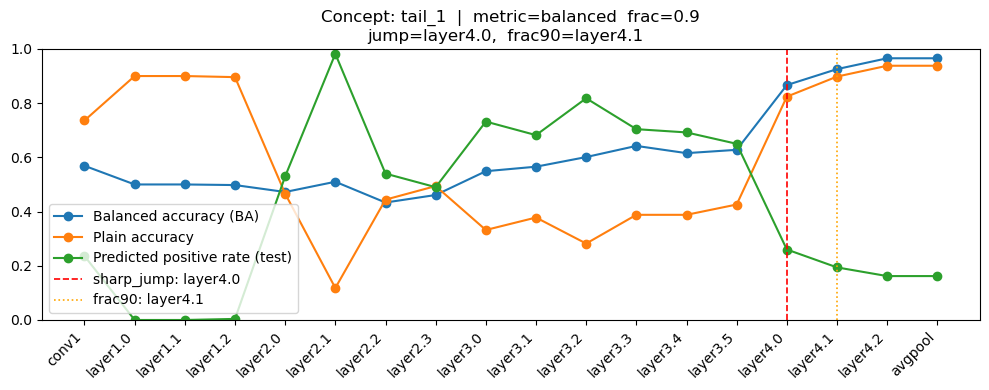

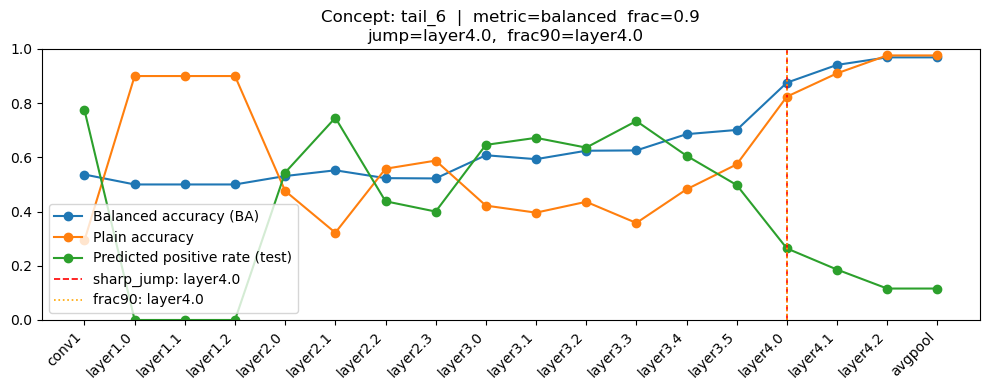

In [33]:
def plot_attribute_curve(attr: str, title_extra="", metric=None, frac=None):
    """
    Plots balanced accuracy, plain accuracy, and predicted positive rate across LAYERS
    for a single FunnyBirds concept, using a binary weighted linear probe.

    metric : "balanced" | "plain" | None (reads EMERGE_METRIC)
    frac   : float | None (reads EMERGE_FRAC)
    Prints inline.
    """
    _metric = metric if metric is not None else EMERGE_METRIC
    _frac   = frac   if frac   is not None else EMERGE_FRAC

    aid   = attr_name_to_id[attr]
    lab   = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=1)
    lab_i = lab.set_index("image_id")
    ytr   = lab_i.loc[aligned_tr_ids, "y"].to_numpy(dtype=np.int32)
    yte   = lab_i.loc[aligned_te_ids, "y"].to_numpy(dtype=np.int32)

    ba_curve, acc_curve, ppos_curve = [], [], []
    for layer in LAYERS:
        ba, acc, ppos, _ = train_linear_probe_binary_weighted(
            aligned_base_tr[layer], ytr,
            aligned_base_te[layer], yte,
            epochs=8, seed=0,
        )
        ba_curve.append(ba); acc_curve.append(acc); ppos_curve.append(ppos)

    ba_arr      = np.asarray(ba_curve,  float)
    acc_arr     = np.asarray(acc_curve, float)
    _emerge_arr = ba_arr if _metric == "balanced" else acc_arr
    e_jump = sharp_rise_idx(_emerge_arr)
    e_frac = frac_of_final_idx(_emerge_arr, frac=_frac)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ba_arr,          marker="o", label="Balanced accuracy (BA)")
    ax.plot(acc_arr,         marker="o", label="Plain accuracy")
    ax.plot(ppos_curve,      marker="o", label="Predicted positive rate (test)")
    ax.axvline(e_jump, color="red",    linestyle="--", linewidth=1.2,
               label=f"sharp_jump: {LAYERS[e_jump]}")
    ax.axvline(e_frac, color="orange", linestyle=":",  linewidth=1.2,
               label=f"frac{int(_frac*100)}: {LAYERS[e_frac]}")
    ax.set_xticks(range(len(LAYERS)))
    ax.set_xticklabels(LAYERS, rotation=45, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_title(
        f"Concept: {attr}  |  metric={_metric}  frac={_frac}\n"
        f"jump={LAYERS[e_jump]},  frac{int(_frac*100)}={LAYERS[e_frac]}  {title_extra}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


# Examples — first and last concept in ATTR_LIST
plot_attribute_curve(SCREENED_ATTR_LIST[1])
plot_attribute_curve(SCREENED_ATTR_LIST[-1])

In [34]:
SCREENED_ATTR_LIST

['tail_5',
 'tail_1',
 'tail_8',
 'eye_0',
 'beak_3',
 'beak_0',
 'foot_3',
 'tail_4',
 'beak_2',
 'tail_3',
 'eye_2',
 'beak_1',
 'wing_4',
 'eye_1',
 'wing_0',
 'wing_1',
 'wing_2',
 'wing_3',
 'wing_5',
 'foot_0',
 'foot_1',
 'foot_2',
 'tail_0',
 'tail_2',
 'tail_6']

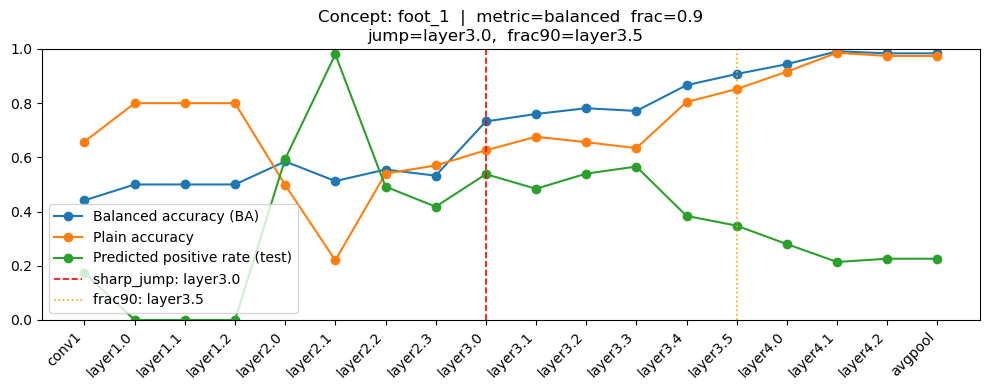

In [35]:
plot_attribute_curve(SCREENED_ATTR_LIST[-5])

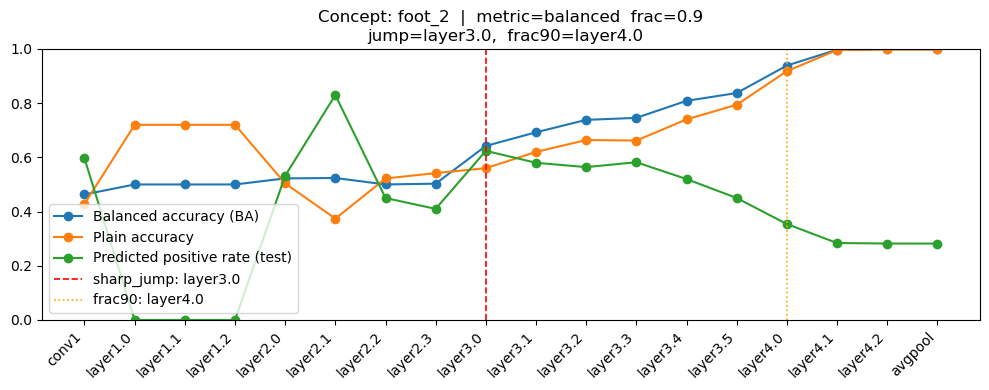

In [36]:
plot_attribute_curve(SCREENED_ATTR_LIST[-4])

In [37]:
print(f"EMERGE_METRIC    : {EMERGE_METRIC}")
print(f"EMERGE_FRAC      : {EMERGE_FRAC}")
print(f"EMERGE_CRITERION : {EMERGE_CRITERION}")
print(f"Species emergence layer (baseline): {LAYERS[species_emerge_idx_ba]}")
print()

for crit, col in [("frac90", "emerge_idx_frac"), ("sharp_jump", "emerge_idx_jump")]:
    at_   = attr_emerge_df[attr_emerge_df[col] == species_emerge_idx_ba]
    after = attr_emerge_df[attr_emerge_df[col] >  species_emerge_idx_ba]
    pre   = attr_emerge_df[attr_emerge_df[col] <  species_emerge_idx_ba]
    print(f"[{crit}]  PRE={len(pre)}  AT={len(at_)}  AFTER={len(after)}")

attr_emerge_df["group"] = "at"
attr_emerge_df.loc[attr_emerge_df[emerge_col] < species_emerge_idx_ba, "group"] = "pre"
attr_emerge_df.loc[attr_emerge_df[emerge_col] > species_emerge_idx_ba, "group"] = "post"

print(f"\nUsing criterion : {EMERGE_CRITERION}")
print("  pre: ",  (attr_emerge_df["group"] == "pre").sum(),
      "  at: ",   (attr_emerge_df["group"] == "at").sum(),
      "  post: ", (attr_emerge_df["group"] == "post").sum())
print()
print(attr_emerge_df[["attr", layer_col, "group", "final_ba", "final_acc",
                       "emerge_metric", "emerge_frac"]])

EMERGE_METRIC    : balanced
EMERGE_FRAC      : 0.9
EMERGE_CRITERION : sharp_jump
Species emergence layer (baseline): layer4.0

[frac90]  PRE=1  AT=22  AFTER=2
[sharp_jump]  PRE=2  AT=23  AFTER=0

Using criterion : sharp_jump
  pre:  2   at:  23   post:  0

      attr emerge_layer_jump group  final_ba  final_acc emerge_metric  \
0   tail_5          layer4.0    at  0.811012      0.708      balanced   
1   tail_1          layer4.0    at  0.965556      0.938      balanced   
2   tail_8          layer4.0    at  0.946429      0.978      balanced   
3    eye_0          layer4.0    at  0.962857      0.948      balanced   
4   beak_3          layer4.0    at  0.922973      0.886      balanced   
5   beak_0          layer4.0    at  0.965517      0.960      balanced   
6   foot_3          layer4.0    at  0.981497      0.980      balanced   
7   tail_4          layer4.0    at  0.881522      0.782      balanced   
8   beak_2          layer4.0    at  0.992045      0.986      balanced   
9   tail_3   


[baseline] Attributes by emergence group:
group
at     23
pre     2
Name: count, dtype: int64

[baseline] Mean gap by emergence group:
          mean       std  count
group                          
at     0.02207  0.021245     23
pre    0.00000  0.000000      2


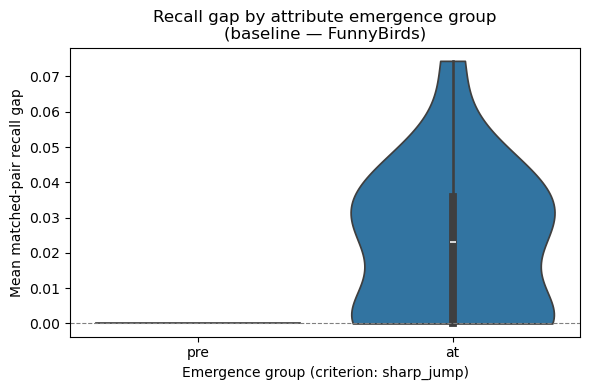


[cbm] Attributes by emergence group:
group
at     23
pre     2
Name: count, dtype: int64

[cbm] Mean gap by emergence group:
           mean       std  count
group                           
at     0.021453  0.031737     23
pre    0.000000  0.000000      2


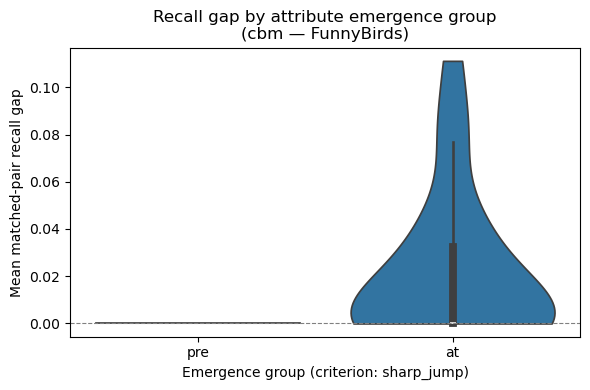

In [38]:
import os
os.makedirs("../figures", exist_ok=True)

for model_name, info_df in [("baseline", baseline_info), ("cbm", cbm_info)]:
    if info_df.empty or "attr" not in info_df.columns:
        print(f"[{model_name}] info_df empty — run run_many first")
        continue
    grp = info_df.merge(
        attr_emerge_df[["attr", "group", emerge_col, layer_col]],
        on="attr", how="left",
    )
    print(f"\n[{model_name}] Attributes by emergence group:")
    print(grp["group"].value_counts())
    print(f"\n[{model_name}] Mean gap by emergence group:")
    print(grp.groupby("group")["mean_gap"].agg(["mean", "std", "count"]))

    order = [g for g in ["pre", "at", "post"] if g in grp["group"].values]

    try:
        import seaborn as sns
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.violinplot(data=grp, x="group", y="mean_gap",
                       order=order, inner="box", cut=0, ax=ax)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xlabel(f"Emergence group (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title(f"Recall gap by attribute emergence group\n"
                     f"({model_name} — FunnyBirds)")
        plt.tight_layout()
        plt.savefig(f"../figures/recall_gap_by_group_fb_{model_name}.pdf", bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"seaborn not available ({e}), using scatter fallback")
        fig, ax = plt.subplots(figsize=(6, 4))
        for g in order:
            vals = grp[grp["group"] == g]["mean_gap"].dropna().values
            ax.scatter([g] * len(vals), vals, alpha=0.6, label=g)
        ax.axhline(0, color="grey", linestyle="--")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title(f"Recall gap by group ({model_name} — FunnyBirds)")
        plt.tight_layout()
        plt.savefig(f"../figures/recall_gap_by_group_fb_{model_name}.pdf", bbox_inches="tight")
        plt.show()

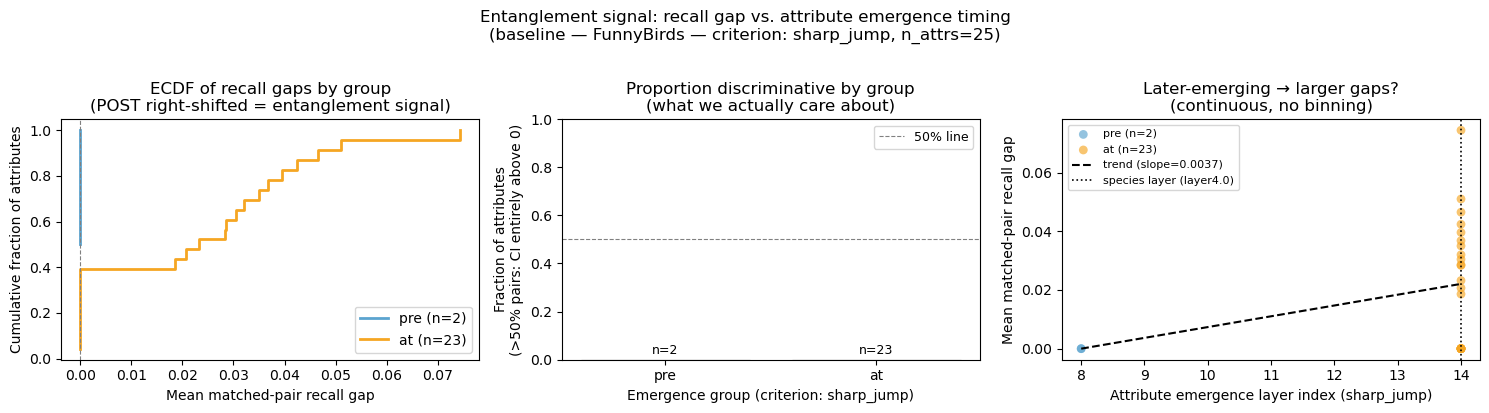

Saved: ../figures/recall_gap_entanglement_fb_baseline.pdf


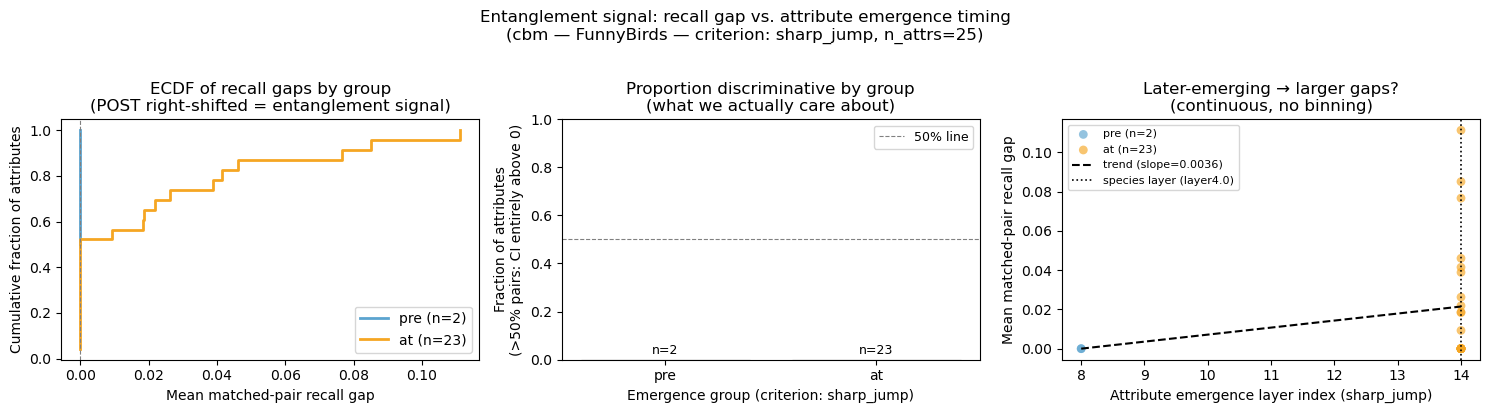

Saved: ../figures/recall_gap_entanglement_fb_cbm.pdf


In [39]:
# ── Better visualization: ECDF + proportion discriminative + scatter trend ─────
# Three views per model:
#   1. ECDF of gap_mean by group       — heavier right tail in POST = signal
#   2. % attributes discriminative     — proportion test, what we actually care about
#   3. Scatter: emergence index vs gap — continuous, no binning, trend line

_egrp       = attr_emerge_df[["attr", "group", emerge_col]].drop_duplicates("attr")
summary_grp = summary.merge(_egrp, on="attr", how="left")
group_order  = [g for g in ["pre", "at", "post"] if g in summary_grp["group"].dropna().values]
group_colors = {"pre": "#5BA4CF", "at": "#F5A623", "post": "#D0021B"}

for model_name in ["baseline", "cbm"]:
    sg = summary_grp[summary_grp["model"] == model_name].copy()
    if sg.empty:
        print(f"[{model_name}] no summary rows — skipping")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # ── Plot 1: ECDF ────────────────────────────────────────────────────────────
    ax = axes[0]
    for g in group_order:
        vals = sg[sg["group"] == g]["gap_mean"].dropna().values
        if len(vals) == 0:
            continue
        vals_s = np.sort(vals)
        ecdf   = np.arange(1, len(vals_s) + 1) / len(vals_s)
        ax.step(vals_s, ecdf, where="post",
                label=f"{g} (n={len(vals)})",
                color=group_colors.get(g), linewidth=2)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Mean matched-pair recall gap")
    ax.set_ylabel("Cumulative fraction of attributes")
    ax.set_title("ECDF of recall gaps by group\n(POST right-shifted = entanglement signal)")
    ax.legend()

    # ── Plot 2: % discriminative ────────────────────────────────────────────────
    ax     = axes[1]
    ci_col = "frac_ci_above0"
    if ci_col in sg.columns:
        disc_rows = []
        for g in group_order:
            sub = sg[sg["group"] == g][ci_col].dropna()
            if len(sub) == 0:
                continue
            disc_rows.append({
                "group": g,
                "frac_discriminative": float((sub > 0.5).mean()),
                "n": len(sub),
            })
        disc_df = pd.DataFrame(disc_rows)
        bars = ax.bar(
            disc_df["group"], disc_df["frac_discriminative"],
            color=[group_colors.get(g, "grey") for g in disc_df["group"]],
            edgecolor="black", linewidth=0.8,
        )
        for bar, row in zip(bars, disc_df.itertuples()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"n={row.n}", ha="center", va="bottom", fontsize=9)
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="50% line")
        ax.set_ylim(0, 1)
        ax.set_xlabel(f"Emergence group (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Fraction of attributes\n(>50% pairs: CI entirely above 0)")
        ax.set_title("Proportion discriminative by group\n(what we actually care about)")
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, "frac_ci_above0 not available\n(run summarize_by_attr first)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Proportion discriminative")

    # ── Plot 3: Scatter — emergence index vs gap_mean ───────────────────────────
    ax = axes[2]
    if emerge_col in sg.columns:
        for g in group_order:
            sub = sg[sg["group"] == g].dropna(subset=["gap_mean", emerge_col])
            if len(sub) == 0:
                continue
            ax.scatter(sub[emerge_col], sub["gap_mean"],
                       label=f"{g} (n={len(sub)})",
                       color=group_colors.get(g), alpha=0.65, s=40, edgecolors="none")
        all_v = sg.dropna(subset=["gap_mean", emerge_col])
        if len(all_v) > 5:
            xs = all_v[emerge_col].values.astype(float)
            ys = all_v["gap_mean"].values
            m, b = np.polyfit(xs, ys, 1)
            xline = np.linspace(xs.min(), xs.max(), 100)
            ax.plot(xline, m * xline + b, color="black", linestyle="--",
                    linewidth=1.5, label=f"trend (slope={m:.4f})")
        ax.axvline(species_emerge_idx_ba, color="black", linestyle=":", linewidth=1.2,
                   label=f"species layer ({LAYERS[species_emerge_idx_ba]})")
        ax.set_xlabel(f"Attribute emergence layer index ({EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title("Later-emerging → larger gaps?\n(continuous, no binning)")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f"Column '{emerge_col}' not in data",
                ha="center", va="center", transform=ax.transAxes)

    plt.suptitle(
        f"Entanglement signal: recall gap vs. attribute emergence timing\n"
        f"({model_name} — FunnyBirds — criterion: {EMERGE_CRITERION}, n_attrs={len(sg)})",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(f"../figures/recall_gap_entanglement_fb_{model_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: ../figures/recall_gap_entanglement_fb_{model_name}.pdf")

In [41]:
grp["group"].values

array(['at', 'at', 'at', 'at', 'at', 'at', 'at', 'at', 'at', 'at', 'at',
       'at', 'at', 'at', 'at', 'at', 'at', 'at', 'at', 'at', 'pre', 'pre',
       'at', 'at', 'at'], dtype=object)

In [49]:
def per_species_gap(pair_summary: pd.DataFrame) -> pd.DataFrame:
    """
    For each species, mean gap across all pairs it appears in.
    High value = probe treats this species very differently from its concept-mates.
    """
    if pair_summary.empty:
        return pair_summary
    a_side = pair_summary[["sid_A", "species_A", "gap_mean"]].rename(
        columns={"sid_A": "species_id", "species_A": "species_name"}
    )
    b_side = pair_summary[["sid_B", "species_B", "gap_mean"]].rename(
        columns={"sid_B": "species_id", "species_B": "species_name"}
    )
    combined = pd.concat([a_side, b_side], ignore_index=True)
    return (
        combined.groupby(["species_id", "species_name"], as_index=False)
        .agg(mean_gap=("gap_mean", "mean"), n_pairs=("gap_mean", "size"),
             max_gap=("gap_mean", "max"))
        .sort_values("mean_gap", ascending=False)
        .reset_index(drop=True)
    )
    
def species_attr_gap(pairs_df: pd.DataFrame) -> pd.DataFrame:
    """Long-form: one row per (species, attr). Shows which attributes drive each species' gap."""
    if pairs_df.empty:
        return pairs_df
    a_side = pairs_df[["attr", "sid_A", "species_A", "gap_mean"]].rename(
        columns={"sid_A": "species_id", "species_A": "species_name"}
    )
    b_side = pairs_df[["attr", "sid_B", "species_B", "gap_mean"]].rename(
        columns={"sid_B": "species_id", "species_B": "species_name"}
    )
    combined = pd.concat([a_side, b_side], ignore_index=True)
    return (
        combined.groupby(["species_id", "species_name", "attr"], as_index=False)
        .agg(mean_gap=("gap_mean", "mean"), n_pairs=("gap_mean", "size"))
        .sort_values(["species_name", "mean_gap"], ascending=[True, False])
        .reset_index(drop=True)
    )

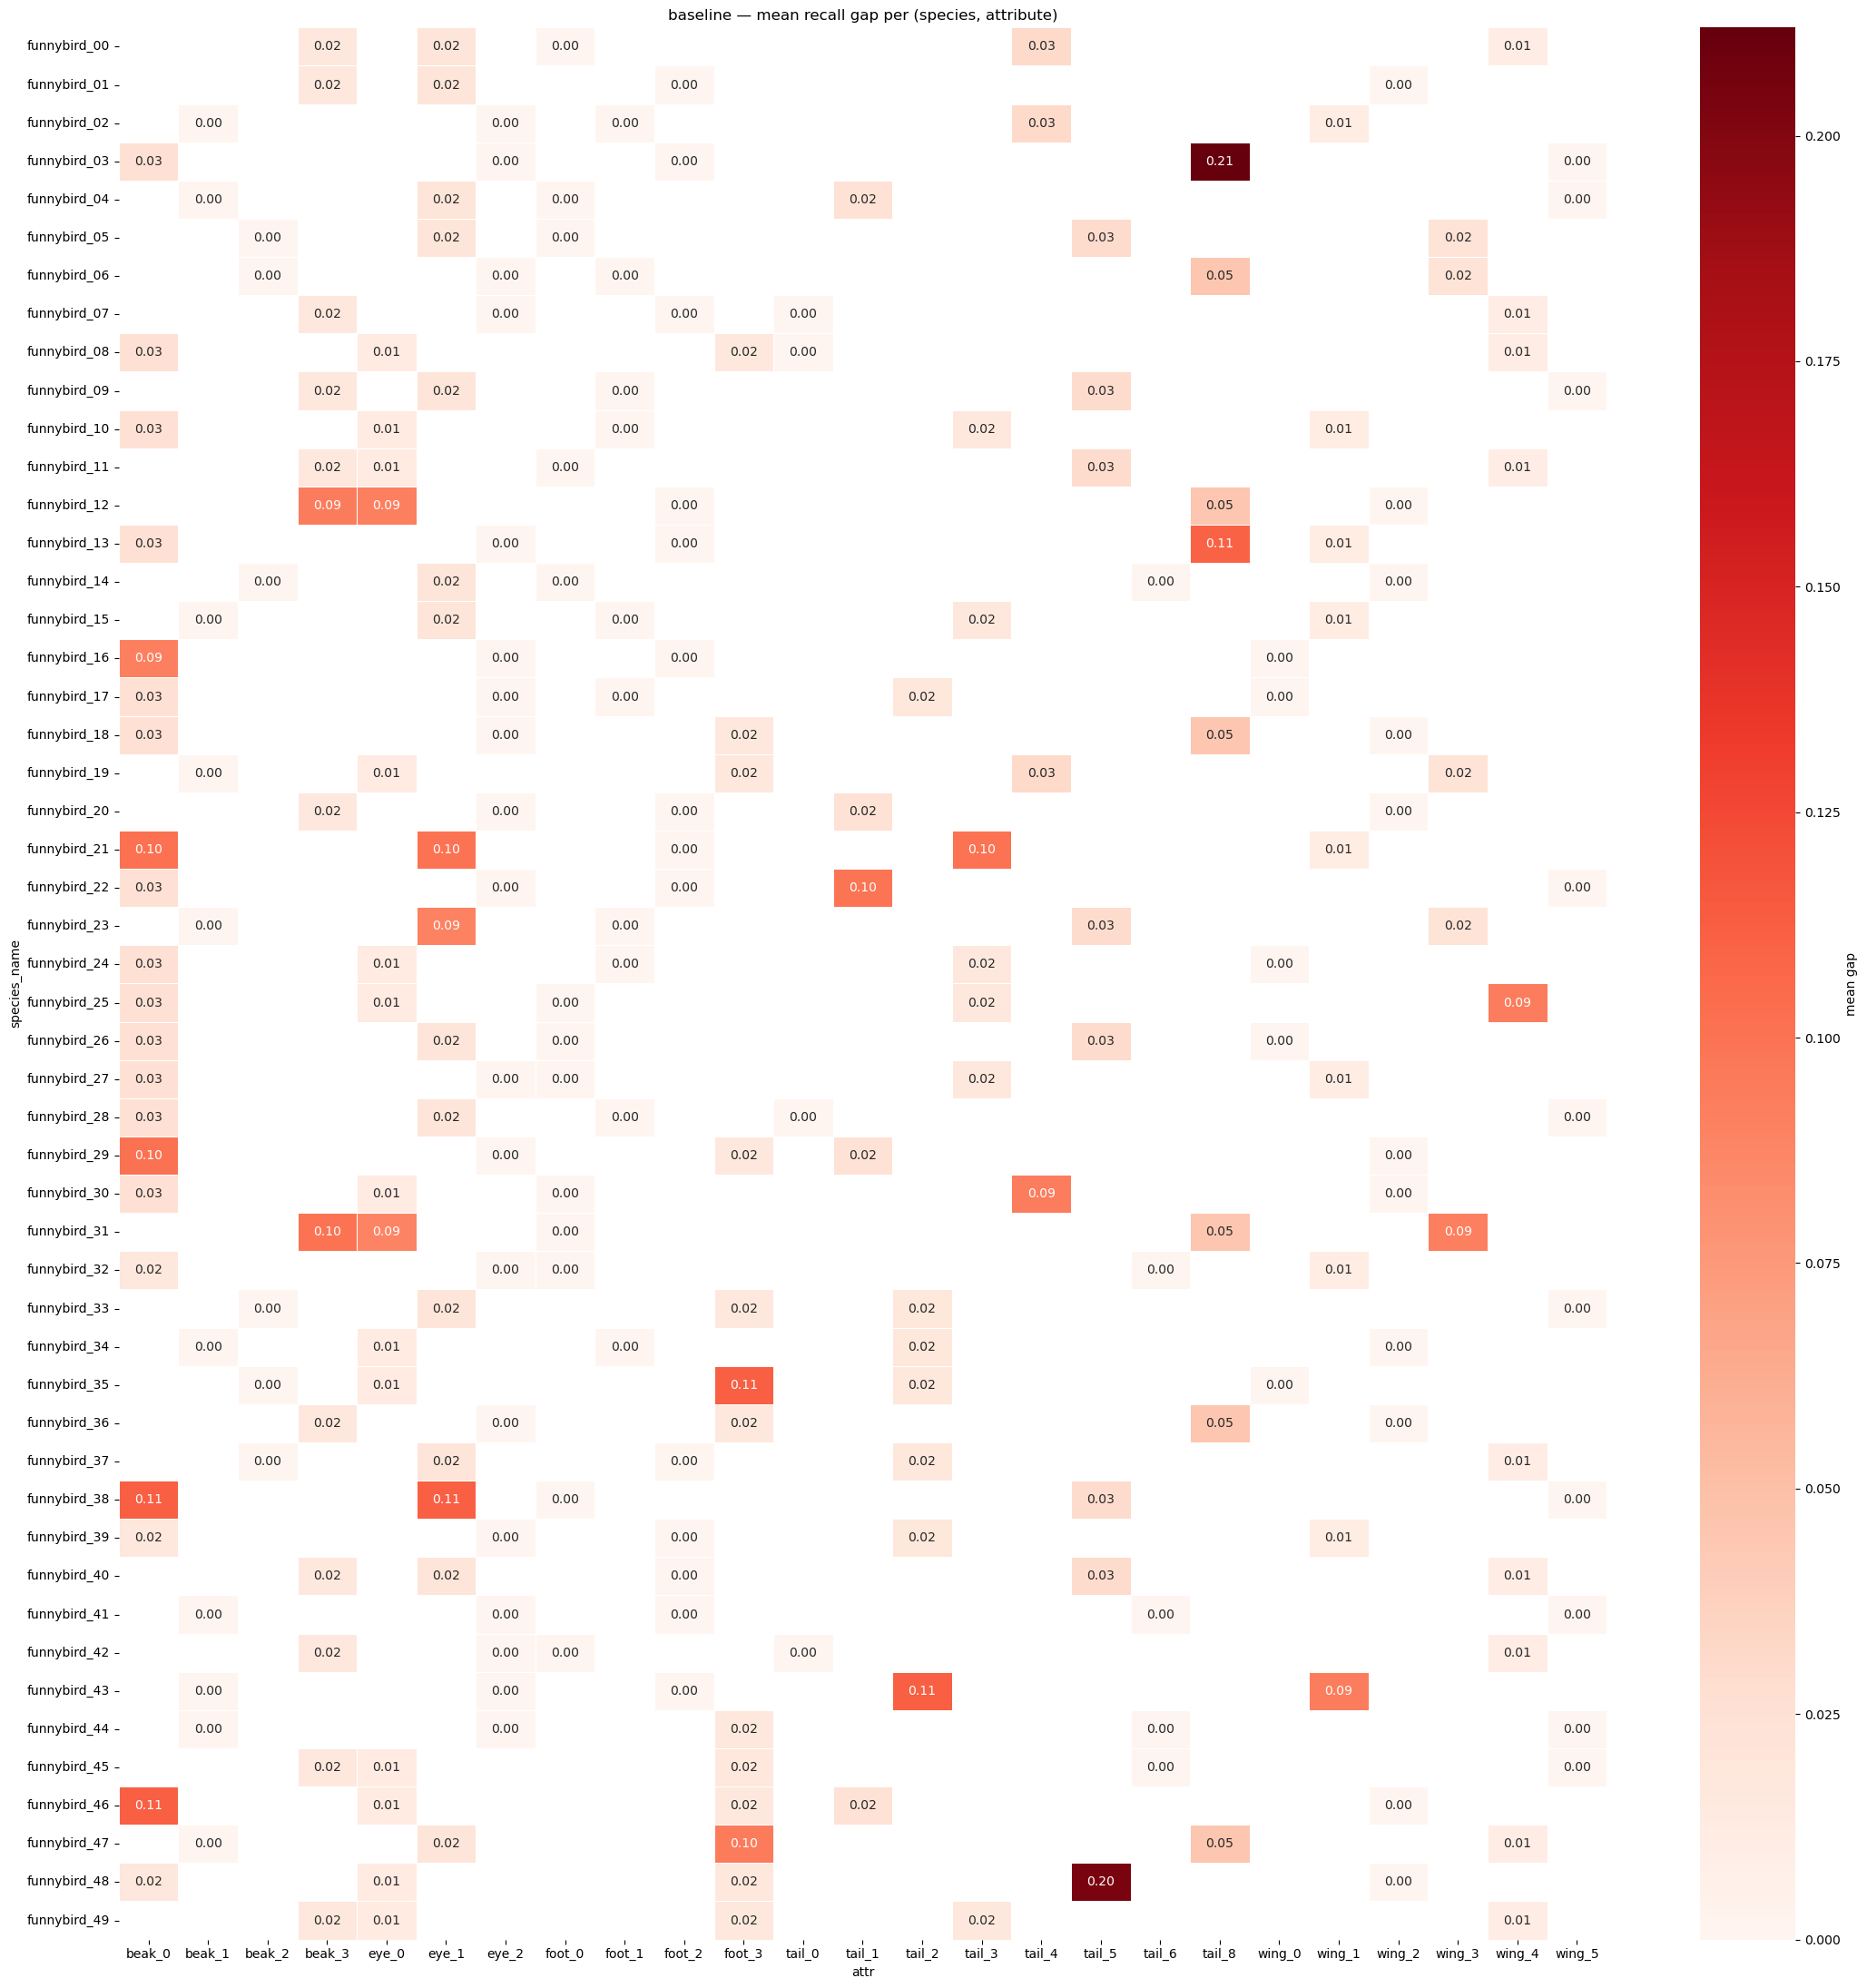

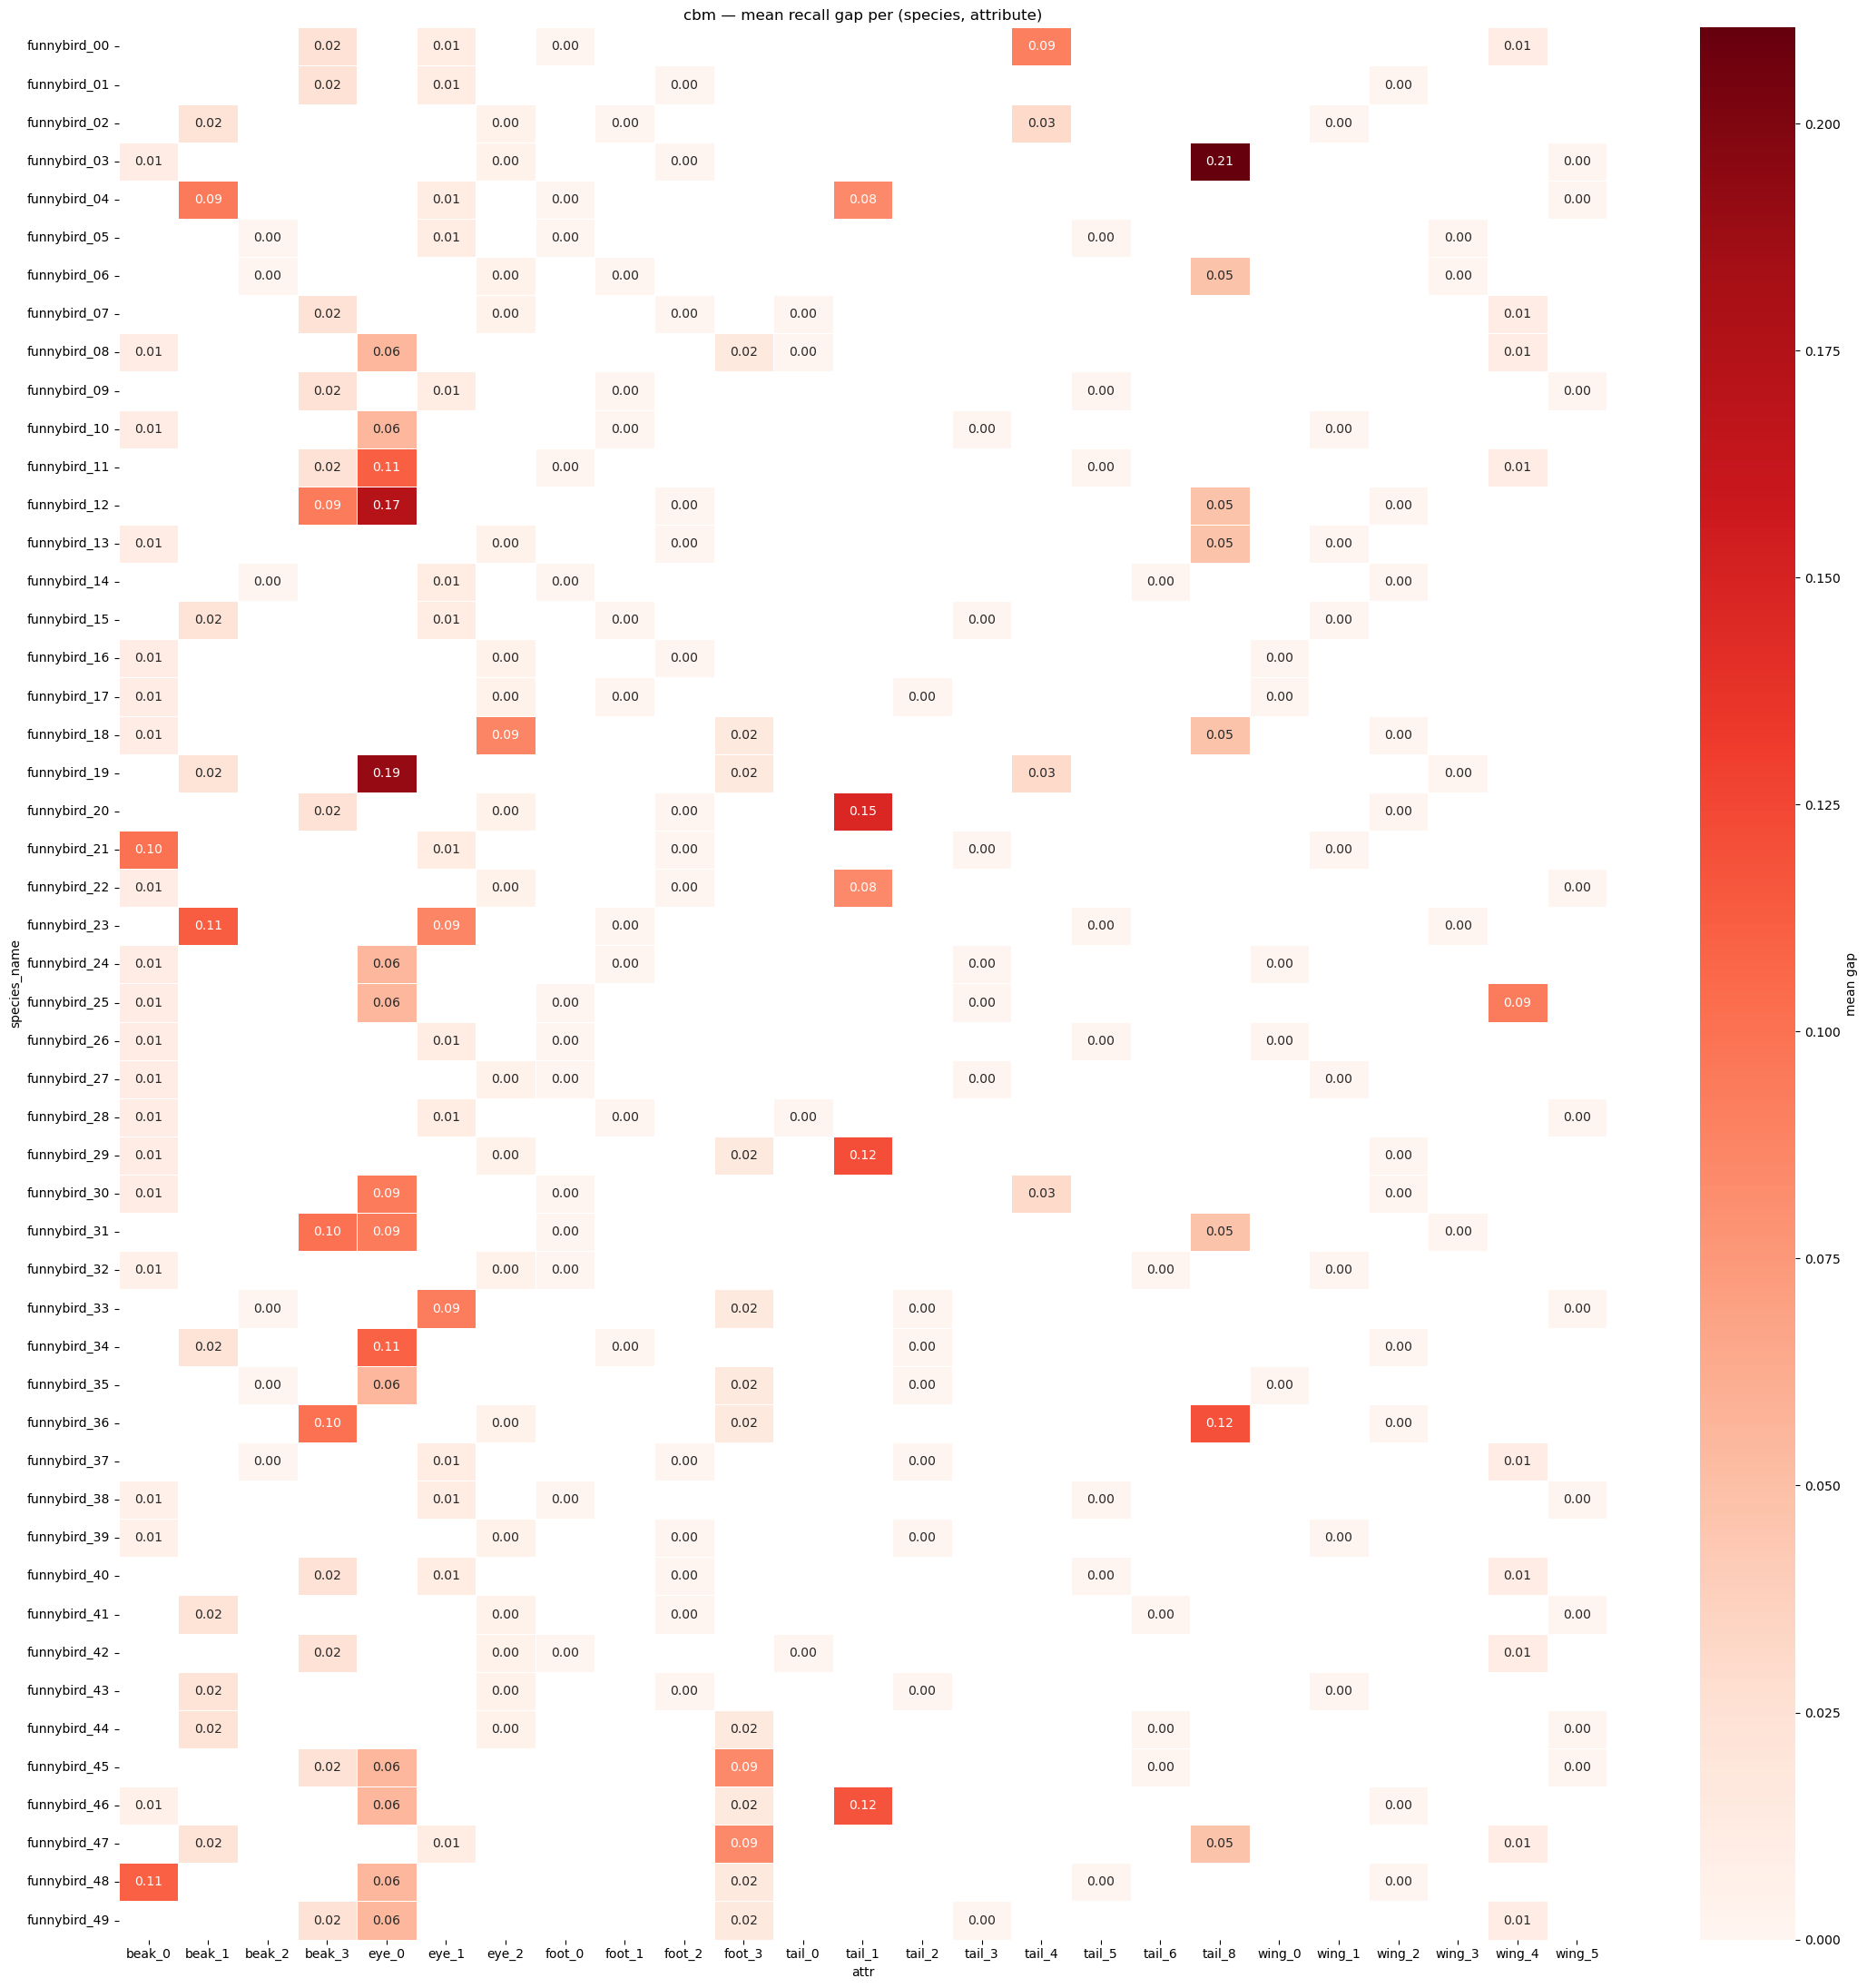

In [50]:
import seaborn as sns

for name, ps in [("baseline", baseline_pairs), ("cbm", cbm_pairs)]:
    if ps.empty:
        continue
    sa    = species_attr_gap(ps)
    pivot = sa.pivot(index="species_name", columns="attr", values="mean_gap")

    fig, ax = plt.subplots(figsize=(len(pivot.columns) * 0.8 + 2, len(pivot) * 0.4 + 2))
    sns.heatmap(pivot, ax=ax, cmap="Reds", annot=True, fmt=".2f",
                linewidths=0.4, cbar_kws={"label": "mean gap"})
    ax.set_title(f"{name} — mean recall gap per (species, attribute)")
    plt.tight_layout()
    plt.show()

In [51]:
def species_attr_recall(species_df: pd.DataFrame, min_pos: int = 3) -> pd.DataFrame:
    """
    For each (species, attr): recall, CI, and deviation from the median recall
    across all species that have the concept.
    Positive deviation = probe fires MORE on this species than average.
    Negative deviation = probe fires LESS.
    """
    df = species_df[species_df["n_pos"] >= min_pos].copy()

    # median recall per attr across all species that have the concept
    attr_median = (
        df.groupby("attr")["recall"]
        .median()
        .rename("attr_median_recall")
    )
    df = df.join(attr_median, on="attr")
    df["recall_dev"] = df["recall"] - df["attr_median_recall"]
    return df[["attr", "species_name", "n_pos", "recall",
               "recall_ci_lo", "recall_ci_hi", "recall_dev",
               "attr_median_recall"]]

def pairs_for_species(pairs_df: pd.DataFrame, species_name: str) -> pd.DataFrame:
    """
    All pairs involving species_name, showing the partner and gap per attr.
    """
    mask_a = pairs_df["species_A"] == species_name
    mask_b = pairs_df["species_B"] == species_name

    a_side = pairs_df[mask_a].copy()
    a_side["partner"] = a_side["species_B"]

    b_side = pairs_df[mask_b].copy()
    b_side["partner"] = b_side["species_A"]

    combined = pd.concat([a_side, b_side], ignore_index=True)
    cols = ["attr", "partner", "gap_mean", "gap_ci_lo", "gap_ci_hi", "gap_p", "npos", "n_runs"]
    cols = [c for c in cols if c in combined.columns]
    return (combined[cols]
            .sort_values("gap_mean", ascending=False)
            .reset_index(drop=True))

In [52]:
for name, sp_df in [("baseline", baseline_species), ("cbm", cbm_species)]:
    sar = species_attr_recall(sp_df)

    # rank species by recall variance across attrs — high variance = inconsistent probe
    sp_var = (
        sar.groupby("species_name")["recall_dev"]
        .agg(recall_dev_std="std", recall_dev_range=lambda x: x.max() - x.min(),
             n_attrs="size")
        .sort_values("recall_dev_std", ascending=False)
        .reset_index()
    )

    print(f"\n{'='*60}\n{name} — species ranked by recall inconsistency across attrs")
    display(sp_var.head(10))

    print(f"\n{name} — worst species: attrs driving deviation")
    worst = sp_var["species_name"].iloc[0]
    sub   = sar[sar["species_name"] == worst].sort_values("recall_dev")
    display(sub)


baseline — species ranked by recall inconsistency across attrs


,species_name,recall_dev_std,recall_dev_range,n_attrs
0,funnybird_48,0.089443,0.2,5
1,funnybird_03,0.089443,0.2,5
2,funnybird_31,0.054772,0.1,5
3,funnybird_21,0.054772,0.1,5
4,funnybird_43,0.054772,0.1,5
5,funnybird_38,0.054772,0.1,5
6,funnybird_12,0.054772,0.1,5
7,funnybird_16,0.050000,0.1,4
8,funnybird_25,0.044721,0.1,5
9,funnybird_29,0.044721,0.1,5



baseline — worst species: attrs driving deviation


,attr,species_name,n_pos,recall,recall_ci_lo,recall_ci_hi,recall_dev,attr_median_recall
23,tail_5,funnybird_48,10,0.8,0.6,1.0,-0.2,1.0
173,eye_0,funnybird_48,10,1.0,1.0,1.0,0.0,1.0
273,beak_0,funnybird_48,10,1.0,1.0,1.0,0.0,1.0
323,foot_3,funnybird_48,10,1.0,1.0,1.0,0.0,1.0
823,wing_2,funnybird_48,10,1.0,1.0,1.0,0.0,1.0



cbm — species ranked by recall inconsistency across attrs


,species_name,recall_dev_std,recall_dev_range,n_attrs
0,funnybird_19,0.089443,0.2,5
1,funnybird_03,0.089443,0.2,5
2,funnybird_12,0.089443,0.2,5
3,funnybird_23,0.054772,0.1,5
4,funnybird_36,0.054772,0.1,5
5,funnybird_31,0.054772,0.1,5
6,funnybird_30,0.044721,0.1,5
7,funnybird_20,0.044721,0.1,5
8,funnybird_21,0.044721,0.1,5
9,funnybird_29,0.044721,0.1,5



cbm — worst species: attrs driving deviation


,attr,species_name,n_pos,recall,recall_ci_lo,recall_ci_hi,recall_dev,attr_median_recall
195,eye_0,funnybird_19,10,0.8,0.6,1.0,-0.2,1.0
345,foot_3,funnybird_19,10,1.0,1.0,1.0,0.0,1.0
395,tail_4,funnybird_19,10,1.0,1.0,1.0,0.0,1.0
595,beak_1,funnybird_19,10,1.0,1.0,1.0,0.0,1.0
895,wing_3,funnybird_19,10,1.0,1.0,1.0,0.0,1.0


In [53]:
for name, ps in [("baseline", baseline_pairs), ("cbm", cbm_pairs)]:
    if ps.empty:
        continue
    sp_rank = per_species_gap(ps)
    print(f"\n{'='*60}\n{name}")
    for _, row in sp_rank.head(5).iterrows():
        sname = row["species_name"]
        print(f"\n  {sname}  (mean_gap={row['mean_gap']:.3f} across {int(row['n_pairs'])} pairs)")
        display(pairs_for_species(ps, sname).head(10))


baseline

  funnybird_21  (mean_gap=0.068 across 62 pairs)


,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,beak_0,funnybird_38,0.112,0.0,0.3,0.48,10,100
1,beak_0,funnybird_46,0.112,0.0,0.3,0.48,10,100
2,beak_0,funnybird_29,0.111,0.0,0.3,0.56,10,100
3,eye_1,funnybird_38,0.111,0.0,0.3,0.50,10,100
4,beak_0,funnybird_16,0.102,0.0,0.3,0.62,10,100
5,tail_3,funnybird_49,0.100,0.0,0.3,0.72,10,100
6,beak_0,funnybird_17,0.100,0.0,0.3,0.72,10,100
7,beak_0,funnybird_10,0.100,0.0,0.3,0.72,10,100
8,beak_0,funnybird_13,0.100,0.0,0.3,0.72,10,100
9,beak_0,funnybird_03,0.100,0.0,0.3,0.72,10,100



  funnybird_31  (mean_gap=0.064 across 49 pairs)


,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,tail_8,funnybird_03,0.218,0.0,0.5,0.20,10,100
1,beak_3,funnybird_12,0.111,0.0,0.3,0.56,10,100
2,tail_8,funnybird_13,0.100,0.0,0.3,0.72,10,100
3,beak_3,funnybird_42,0.099,0.0,0.3,0.68,10,100
4,beak_3,funnybird_20,0.099,0.0,0.3,0.68,10,100
5,beak_3,funnybird_00,0.099,0.0,0.3,0.68,10,100
6,beak_3,funnybird_09,0.099,0.0,0.3,0.68,10,100
7,beak_3,funnybird_07,0.099,0.0,0.3,0.68,10,100
8,beak_3,funnybird_45,0.099,0.0,0.3,0.68,10,100
9,beak_3,funnybird_36,0.099,0.0,0.3,0.68,10,100



  funnybird_38  (mean_gap=0.062 across 59 pairs)


...

,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,tail_8,funnybird_03,0.218,0.0,0.5000,0.20,10,100
1,eye_0,funnybird_19,0.163,0.0,0.5000,0.48,10,100
2,eye_0,funnybird_12,0.141,0.0,0.4525,0.48,10,100
3,eye_0,funnybird_34,0.119,0.0,0.3000,0.64,10,100
4,tail_8,funnybird_36,0.112,0.0,0.3000,0.64,10,100
5,beak_3,funnybird_36,0.111,0.0,0.3000,0.56,10,100
6,beak_3,funnybird_12,0.111,0.0,0.3000,0.56,10,100
7,eye_0,funnybird_11,0.107,0.0,0.3000,0.66,10,100
8,beak_3,funnybird_01,0.099,0.0,0.3000,0.68,10,100
9,beak_3,funnybird_20,0.099,0.0,0.3000,0.68,10,100



  funnybird_23  (mean_gap=0.053 across 44 pairs)


,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,beak_1,funnybird_04,0.116,0.0,0.3,0.54,10,100
1,beak_1,funnybird_19,0.112,0.0,0.3,0.64,10,100
2,beak_1,funnybird_34,0.112,0.0,0.3,0.64,10,100
3,beak_1,funnybird_41,0.112,0.0,0.3,0.64,10,100
4,beak_1,funnybird_43,0.112,0.0,0.3,0.64,10,100
5,beak_1,funnybird_44,0.112,0.0,0.3,0.64,10,100
6,beak_1,funnybird_47,0.112,0.0,0.3,0.64,10,100
7,beak_1,funnybird_15,0.112,0.0,0.3,0.64,10,100
8,beak_1,funnybird_02,0.112,0.0,0.3,0.64,10,100
9,eye_1,funnybird_01,0.088,0.0,0.3,0.80,10,100



  funnybird_48  (mean_gap=0.046 across 59 pairs)


,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,eye_0,funnybird_19,0.211,0.0,0.5,0.24,10,100
1,eye_0,funnybird_12,0.185,0.0,0.5,0.24,10,100
2,beak_0,funnybird_27,0.111,0.0,0.3,0.62,10,100
3,beak_0,funnybird_24,0.111,0.0,0.3,0.62,10,100
4,beak_0,funnybird_28,0.111,0.0,0.3,0.62,10,100
5,beak_0,funnybird_30,0.111,0.0,0.3,0.62,10,100
6,beak_0,funnybird_10,0.111,0.0,0.3,0.62,10,100
7,beak_0,funnybird_22,0.111,0.0,0.3,0.62,10,100
8,beak_0,funnybird_13,0.111,0.0,0.3,0.62,10,100
9,beak_0,funnybird_03,0.111,0.0,0.3,0.62,10,100


In [54]:
def species_summary(species_df, pairs_df, min_pos=3):
    sar      = species_attr_recall(species_df, min_pos=min_pos)
    inc      = (sar.groupby("species_name")["recall_dev"]
                   .agg(recall_dev_std="std", recall_dev_range=lambda x: x.max()-x.min())
                   .reset_index())
    gap_rank = per_species_gap(pairs_df)[["species_name", "mean_gap", "max_gap"]]
    return (inc.merge(gap_rank, on="species_name", how="outer")
               .sort_values("mean_gap", ascending=False)
               .reset_index(drop=True))

In [55]:
for name, sp_df, ps in [("baseline", baseline_species, baseline_pairs),
                         ("cbm",      cbm_species,      cbm_pairs)]:
    if ps.empty or sp_df.empty:
        continue
    print(f"\n{name}")
    display(species_summary(sp_df, ps).head(20))


baseline


,species_name,recall_dev_std,recall_dev_range,mean_gap,max_gap
0,funnybird_21,0.054772,0.1,0.068081,0.112
1,funnybird_31,0.054772,0.1,0.063837,0.218
2,funnybird_38,0.054772,0.1,0.062271,0.204
3,funnybird_12,0.054772,0.1,0.048839,0.218
4,funnybird_46,0.044721,0.1,0.040625,0.112
5,funnybird_35,0.044721,0.1,0.040073,0.119
6,funnybird_23,0.044721,0.1,0.037386,0.204
7,funnybird_29,0.044721,0.1,0.036156,0.112
8,funnybird_47,0.044721,0.1,0.035615,0.218
9,funnybird_48,0.089443,0.2,0.035593,0.204



cbm


,species_name,recall_dev_std,recall_dev_range,mean_gap,max_gap
0,funnybird_19,0.089443,0.2,0.075071,0.211
1,funnybird_12,0.089443,0.2,0.069321,0.218
2,funnybird_31,0.054772,0.1,0.058449,0.218
3,funnybird_23,0.054772,0.1,0.052977,0.116
4,funnybird_48,0.044721,0.1,0.046339,0.211
5,funnybird_45,0.044721,0.1,0.041059,0.211
6,funnybird_36,0.054772,0.1,0.039373,0.166
7,funnybird_34,0.044721,0.1,0.036229,0.168
8,funnybird_11,0.044721,0.1,0.036093,0.146
9,funnybird_21,0.044721,0.1,0.035226,0.103


## Species-level diagnostic: gap vs. recall inconsistency

Two separate failure modes for a concept probe:

**`mean_gap`** (from paired species comparisons)
For a concept both species A and B have, does the probe fire at different rates?
High = probe treats this species differently *relative to its concept-mates*.
Source: `baseline_pairs` / `cbm_pairs`.

**`recall_dev_std`** (from per-species recall across attributes)
Across all attributes this species has, does the probe recall it consistently?
High = probe is variable on this species across concepts, regardless of what other species do.
Source: `baseline_species` / `cbm_species`.

These are orthogonal:

|                        | Low `mean_gap`                          | High `mean_gap`                            |
|------------------------|-----------------------------------------|--------------------------------------------|
| **Low `recall_dev_std`**  | Probe is consistent and fair            | Probe systematically over/under-fires on this species across all concepts |
| **High `recall_dev_std`** | Probe varies by concept but fairly across species | Probe is both concept-inconsistent **and** species-biased — worst case |

The bottom-right cell is the primary signal of species-identity entanglement.
`species_summary()` combines both metrics into one table so you can identify species in that cell directly.

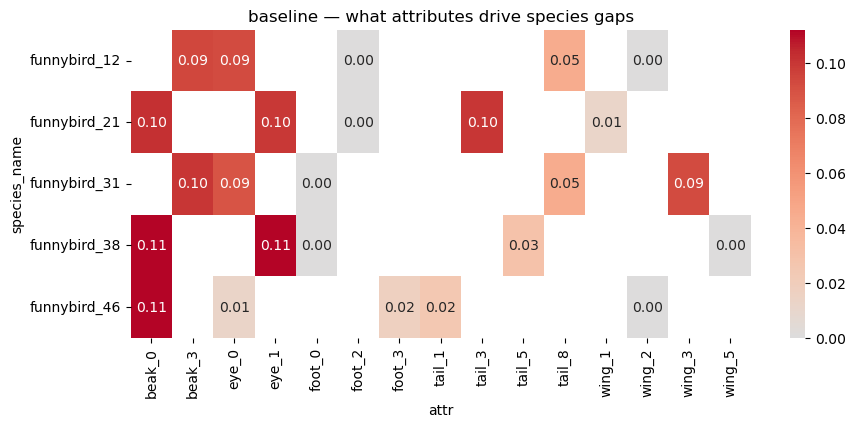

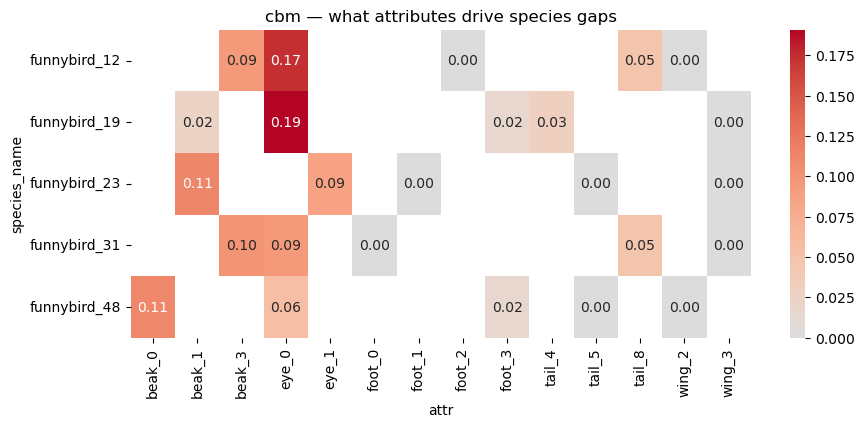

In [56]:
for name, ps in [("baseline", baseline_pairs), ("cbm", cbm_pairs)]:
    if ps.empty:
        continue

    sa = species_attr_gap(ps)

    # focus on top unstable species
    top_species = (
        per_species_gap(ps)["species_name"]
        .head(5)
        .tolist()
    )

    sub = sa[sa["species_name"].isin(top_species)]

    pivot = sub.pivot(index="species_name", columns="attr", values="mean_gap")

    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title(f"{name} — what attributes drive species gaps")
    plt.show()

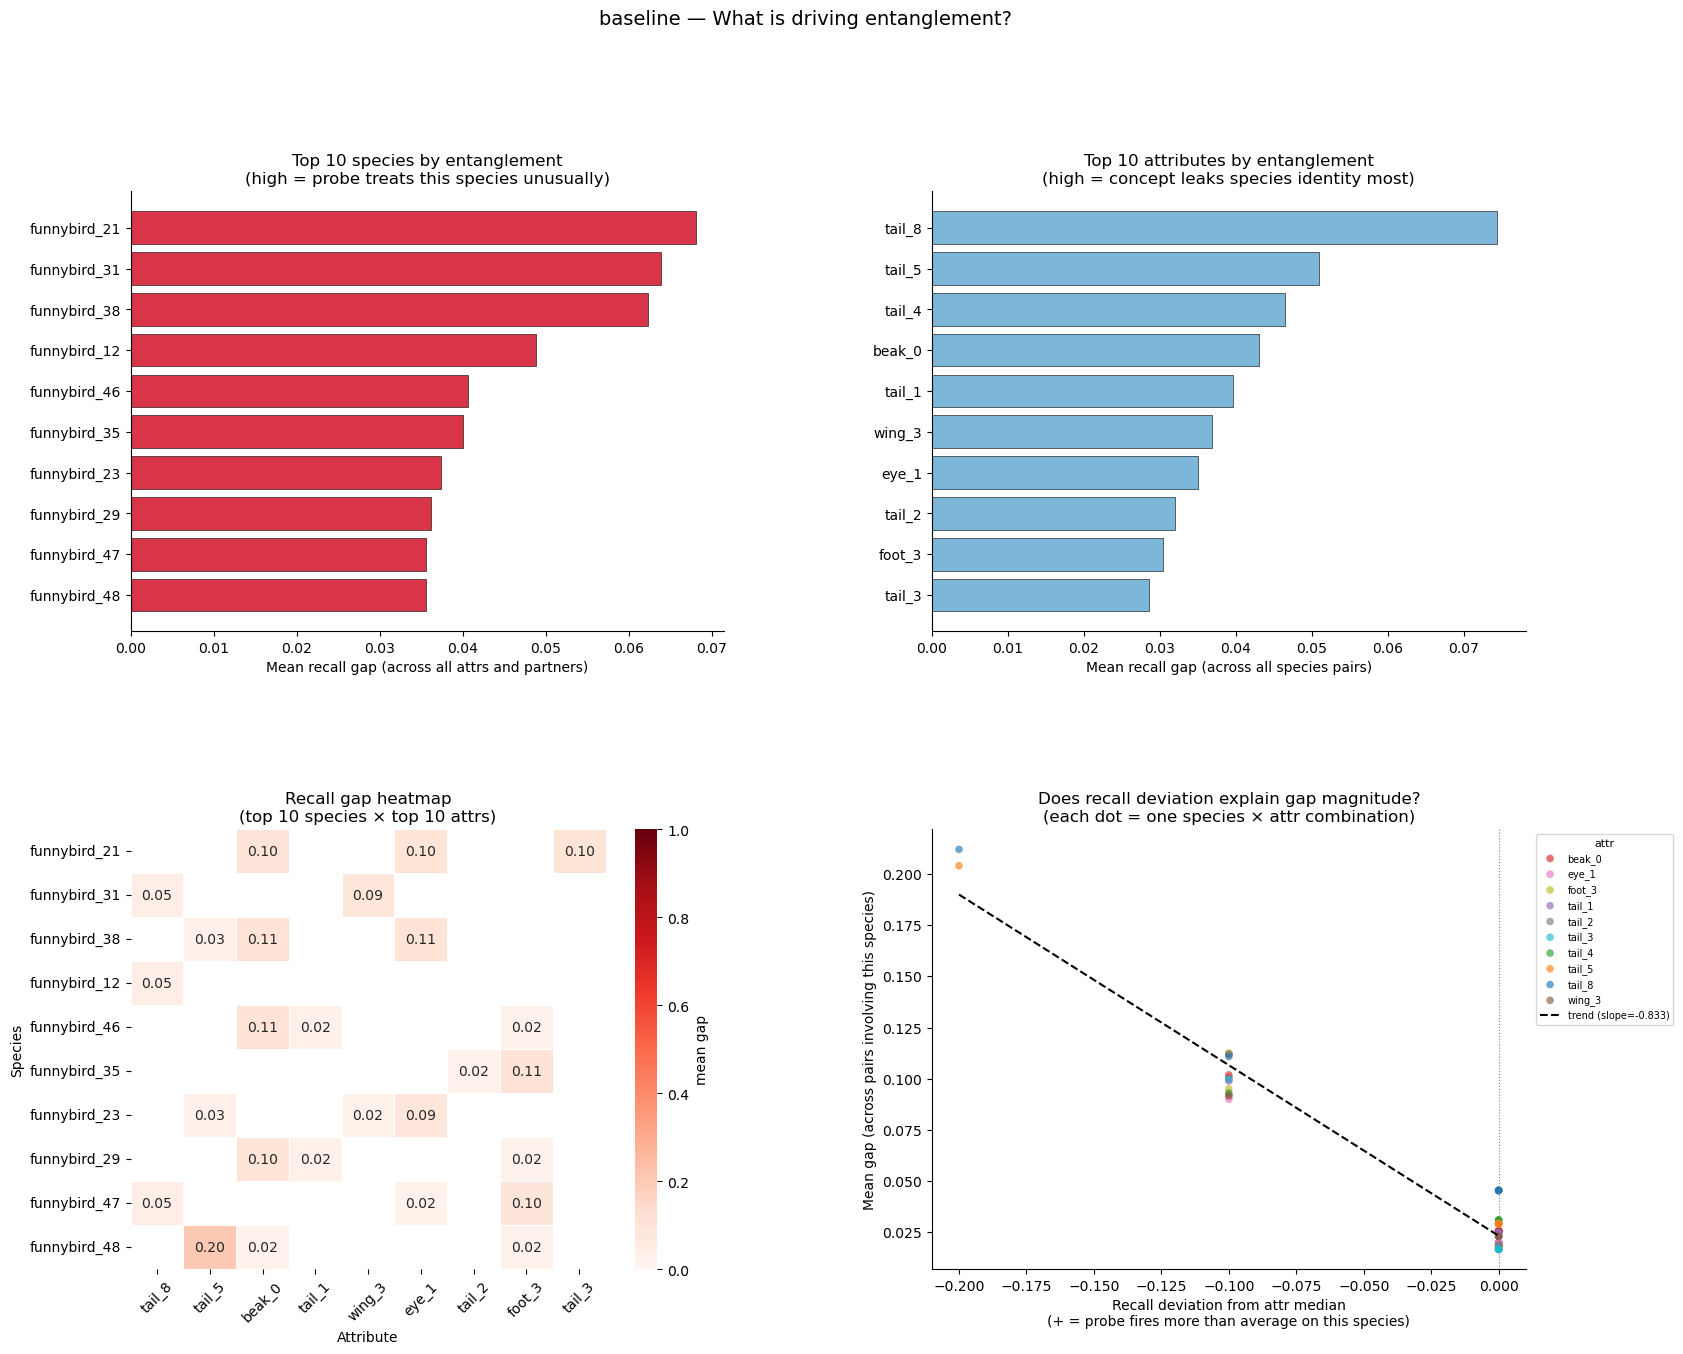

Saved: ../figures/species_gap_summary_fb_baseline.pdf


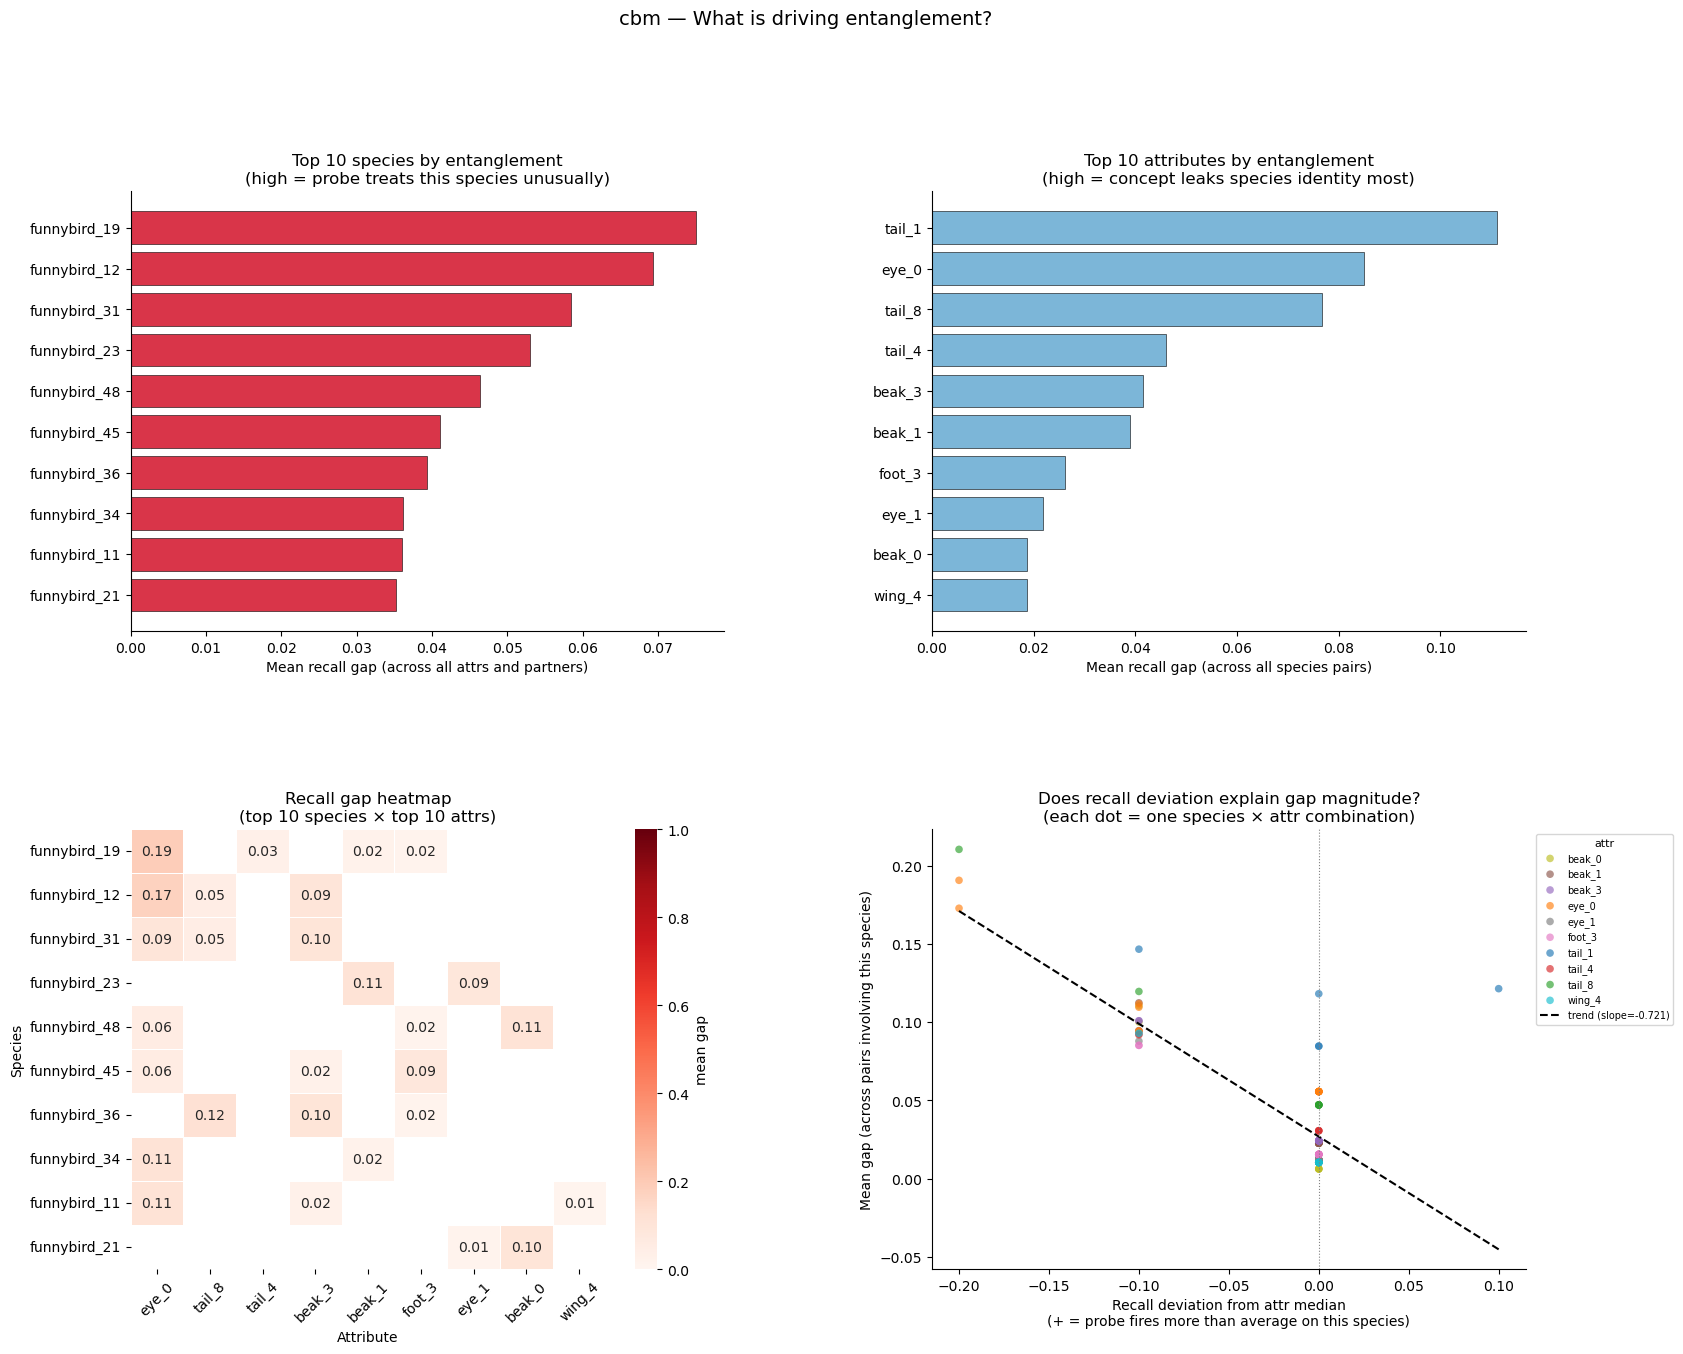

Saved: ../figures/species_gap_summary_fb_cbm.pdf


In [57]:
import seaborn as sns

def plot_species_gap_summary(
    pairs_df: pd.DataFrame,
    species_df: pd.DataFrame,
    model_name: str,
    top_n_species: int = 10,
    top_n_attrs: int = 10,
):
    """
    Four-panel figure per model:
      1. Bar chart   — top species by mean gap (who is most entangled overall)
      2. Bar chart   — top attrs by mean gap (which concepts drive entanglement)
      3. Heatmap     — species x attr gap (where they intersect)
      4. Scatter     — recall_dev vs gap_mean per (species, attr)
                       (does high gap = high deviation from median recall?)
    """
    if pairs_df.empty or species_df.empty:
        print(f"[{model_name}] no data")
        return

    # ── build the three tables ─────────────────────────────────────────────────
    sp_rank = per_species_gap(pairs_df)
    sa      = species_attr_gap(pairs_df)
    sar     = species_attr_recall(species_df)

    # restrict to top N for readability
    top_species = sp_rank["species_name"].head(top_n_species).tolist()
    attr_order  = (
        sa.groupby("attr")["mean_gap"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n_attrs)
        .index.tolist()
    )

    # ── figure ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 14))
    gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    # ── Panel 1: top species by mean gap ───────────────────────────────────────
    sp_top = sp_rank.head(top_n_species)
    ax1.barh(sp_top["species_name"][::-1], sp_top["mean_gap"][::-1],
             color="#D0021B", alpha=0.8, edgecolor="black", linewidth=0.5)
    ax1.set_xlabel("Mean recall gap (across all attrs and partners)")
    ax1.set_title(f"Top {top_n_species} species by entanglement\n"
                  f"(high = probe treats this species unusually)")
    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)

    # ── Panel 2: top attrs by mean gap ─────────────────────────────────────────
    attr_means = (
        sa.groupby("attr")["mean_gap"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n_attrs)
        .reset_index()
    )
    ax2.barh(attr_means["attr"][::-1], attr_means["mean_gap"][::-1],
             color="#5BA4CF", alpha=0.8, edgecolor="black", linewidth=0.5)
    ax2.set_xlabel("Mean recall gap (across all species pairs)")
    ax2.set_title(f"Top {top_n_attrs} attributes by entanglement\n"
                  f"(high = concept leaks species identity most)")
    for spine in ["top", "right"]:
        ax2.spines[spine].set_visible(False)

    # ── Panel 3: heatmap species x attr (top N each) ───────────────────────────
    sa_top = sa[
        sa["species_name"].isin(top_species) &
        sa["attr"].isin(attr_order)
    ]
    pivot = sa_top.pivot(index="species_name", columns="attr", values="mean_gap")
    # reorder rows by sp_rank order, columns by attr_order
    pivot = pivot.reindex(index=[s for s in top_species if s in pivot.index],
                          columns=[a for a in attr_order if a in pivot.columns])
    sns.heatmap(
        pivot, ax=ax3, cmap="Reds", annot=True, fmt=".2f",
        linewidths=0.4, cbar_kws={"label": "mean gap"},
        vmin=0, vmax=1,
    )
    ax3.set_title(f"Recall gap heatmap\n(top {top_n_species} species × top {top_n_attrs} attrs)")
    ax3.set_xlabel("Attribute")
    ax3.set_ylabel("Species")
    ax3.tick_params(axis="x", rotation=45)
    ax3.tick_params(axis="y", rotation=0)

    # ── Panel 4: scatter recall_dev vs gap_mean ────────────────────────────────
    # merge sar (recall deviation) with sa (gap) on (species_name, attr)
    merged = sar.merge(
        sa[["species_name", "attr", "mean_gap"]],
        on=["species_name", "attr"], how="inner"
    )
    # colour by attr, only top attrs for clarity
    merged_top = merged[merged["attr"].isin(attr_order)]

    palette = sns.color_palette("tab10", n_colors=len(attr_order))
    color_map = dict(zip(attr_order, palette))

    for attr_name, grp in merged_top.groupby("attr"):
        ax4.scatter(
            grp["recall_dev"], grp["mean_gap"],
            label=attr_name,
            color=color_map.get(attr_name, "grey"),
            alpha=0.65, s=30, edgecolors="none",
        )
    # trend line
    if len(merged_top) > 5:
        xs = merged_top["recall_dev"].values
        ys = merged_top["mean_gap"].values
        finite = np.isfinite(xs) & np.isfinite(ys)
        if finite.sum() > 5:
            m, b = np.polyfit(xs[finite], ys[finite], 1)
            xline = np.linspace(xs[finite].min(), xs[finite].max(), 100)
            ax4.plot(xline, m * xline + b, color="black", linestyle="--",
                     linewidth=1.5, label=f"trend (slope={m:.3f})")
    ax4.axvline(0, color="grey", linestyle=":", linewidth=0.8)
    ax4.set_xlabel("Recall deviation from attr median\n"
                   "(+ = probe fires more than average on this species)")
    ax4.set_ylabel("Mean gap (across pairs involving this species)")
    ax4.set_title("Does recall deviation explain gap magnitude?\n"
                  "(each dot = one species × attr combination)")
    ax4.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left",
               title="attr", title_fontsize=8)
    for spine in ["top", "right"]:
        ax4.spines[spine].set_visible(False)

    fig.suptitle(
        f"{model_name} — What is driving entanglement?",
        fontsize=14, y=1.01,
    )
    plt.savefig(f"../figures/species_gap_summary_fb_{model_name}.pdf",
                bbox_inches="tight")
    plt.show()
    print(f"Saved: ../figures/species_gap_summary_fb_{model_name}.pdf")


for model_name, pairs_df, species_df in [
    ("baseline", baseline_pairs, baseline_species),
    ("cbm",      cbm_pairs,      cbm_species),
]:
    plot_species_gap_summary(pairs_df, species_df, model_name,
                             top_n_species=10, top_n_attrs=10)